In [1]:
import pandas as pd
import numpy as np

# Load Data

In [2]:
# # To save engineered features dataset

# df = pd.read_parquet('sampling/data/combined_dataset.parquet')

# df = df.drop(columns=['category'])
# df = df.dropna(subset=['sent_at', 'date'])

# # Ensure datetime columns are in datetime format
# time_cols = [
#     'sent_at', 'opened_first_time_at', 'opened_last_time_at',
#     'clicked_first_time_at', 'clicked_last_time_at', 'purchased_at'
# ]
# for col in time_cols:
#     df[col] = pd.to_datetime(df[col])

# # Sort messages by client_id and sent time
# df = df.sort_values(['client_id', 'sent_at'])


# import sys

# sys.path.append('src/')

# import src.feature_engineering as feat_eng
# from src import data_loading as loader
# from src import preprocess_for_fe as preprocessor

# df = loader.load_data('sampling/data/combined_dataset.parquet')
# df = preprocessor.prepare_data(df)
# df = preprocessor.clean_data(df)
# df = feat_eng.engineer_all_features(df)

In [2]:
# To load engineered features dataset
df = pd.read_parquet('sampling/data/whole_df_with_fe.parquet')

In [3]:
# Ensure datetime columns are in datetime format
time_cols = [
    'sent_at', 'opened_first_time_at', 'opened_last_time_at',
    'clicked_first_time_at', 'clicked_last_time_at', 'purchased_at'
]
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# Sort messages by client_id and sent time
df = df.sort_values(['client_id', 'sent_at'])

In [4]:
df.shape

(1562021, 221)

# Proxy Variables

In [5]:
proxies_df = df[['message_id', 'client_id', 'is_opened']]

## Expected Value

### Prior Belief (miu)

In [6]:
# 'is_opened_rate_1m', 'is_opened_rate_prev_smooth', 'is_opened_expect_gap_1m', 
# 'is_clicked_rate_1m', 'is_clicked_rate_prev_smooth', 'is_opened_rate_campaign_per_client'
# 'is_clicked_rate_campaign_per_client', 'is_purchased_rate_campaign_per_client', 
#  'is_purchased_rate_prev_smooth'

In [7]:
prior_belief_df = df[['message_id',
                    #   'is_opened_rate_1m', 
                      'is_opened_rate_prev_smooth', 
                      # 'is_opened_expect_gap_1m',
                    #   'is_clicked_rate_1m', 
                      # 'is_clicked_rate_prev_smooth'
                      ]]

In [8]:
prior_belief_df.isnull().sum().sort_values(ascending=False) / prior_belief_df.shape[0]

message_id                    0.0
is_opened_rate_prev_smooth    0.0
dtype: float64

Those nulls are for new clients. As our goal is not to build a model that can be deployed for real world scenario, and we are just trying to analyze the data from economic model perspective, we will simply delete those rows to avoid adding noise to the data.

### Prior Precision (tau)

In [9]:
# weekly open rates variance, if null fill with max variance (new clients have the lowest precision)

In [10]:
prior_precision_df = df[['message_id', 'open_rate_14d_prior_var']] 

In [11]:
prior_precision_df.isnull().sum().sort_values(ascending=False) / prior_precision_df.shape[0]

open_rate_14d_prior_var    0.05605
message_id                 0.00000
dtype: float64

<Axes: >

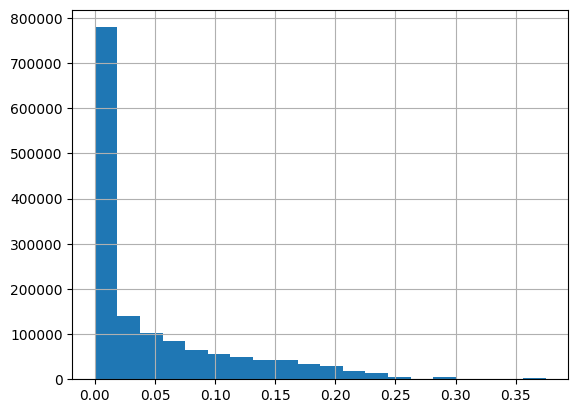

In [12]:
prior_precision_df['open_rate_14d_prior_var'].hist(bins=20)

In [13]:
prior_precision_df['open_rate_14d_prior_var'].value_counts(dropna=False)

open_rate_14d_prior_var
0.000000    505872
NaN          87551
0.234375      4337
0.296296      3919
0.375000      3247
             ...  
0.172752         1
0.182520         1
0.188614         1
0.183299         1
0.185333         1
Name: count, Length: 407989, dtype: int64

<Axes: >

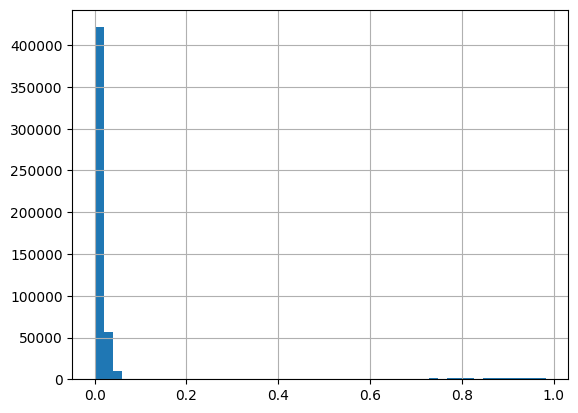

In [14]:
df[df['open_rate_14d_prior_var'] == 0]['is_opened_rate_prev_smooth'].hist(bins=50)

Variance is null for new clients (or at least clients who was not contacted during the available time frame)
As our goal is not to build a model that can be deployed for real world scenario, and we are just trying to analyze the data from economic model perspective, we will simply delete those rows to avoid adding noise to the data.

### Signal

In [15]:
# 'subject_with_bonuses', 'subject_with_deadline', 'subject_with_personalization', 'subject_with_saleout', 'subject_with_emoji'
# topic is happy birthday
# number of those keywords mentioned in the subject line
# number of those keywords divided on the length of the subject
# days until next holiday
#  is_opened_rate_campaign, is_clicked_rate_campaign, is_purchased_rate_campaign
# we assume that those variables describe how valuable the signal could be for a client

In [16]:
df.topic.value_counts()

topic
sale out                1527930
welcome campaign           7746
happy birthday             1888
offer after purchase       1384
event                       522
leave review                151
Name: count, dtype: int64

In [17]:
signal_df = df[['message_id', 'subject_length',
                      'subject_with_bonuses', 
                      # 'subject_with_deadline', 
                      'subject_with_personalization', 
                      # 'subject_with_saleout',
                    #   'subject_with_emoji', 
                      'topic',
                      # 'is_opened_rate_campaign', 
                      # 'is_clicked_rate_campaign', 
                      # 'is_purchased_rate_campaign',
                      # 'days_until_next_holiday', 
                      # 'days_since_last_holiday'
                      ]]

# signal_df['number_of_keywords_in_subject'] = (signal_df['subject_with_bonuses'].astype(int) +
#                                               signal_df['subject_with_deadline'].astype(int)  +
#                                               signal_df['subject_with_personalization'].astype(int)  +
#                                               signal_df['subject_with_saleout'].astype(int)
                                            #   signal_df['subject_with_emoji'].astype(int) 
                                            # )

# signal_df['keywords_compare_with_length'] = signal_df['number_of_keywords_in_subject'] / signal_df['subject_length']

# signal_df['birthday_message'] = np.where(signal_df['topic'] == 'happy birthday', 1, 0)
# signal_df['welcome_message'] = np.where(signal_df['topic'] == 'welcome campaign', 1, 0)
# signal_df['offer_after_purchase_message'] = np.where(signal_df['topic'] == 'offer after purchase', 1, 0)


signal_df = signal_df.drop(columns=['subject_length', 'topic',
                                    # 'subject_with_bonuses', 
                      # 'subject_with_deadline', 
                      # 'subject_with_personalization', 
                      # 'subject_with_saleout'
                      ])

In [18]:
signal_df.columns

Index(['message_id', 'subject_with_bonuses', 'subject_with_personalization'], dtype='object')

In [19]:
# signal_df['number_of_keywords_in_subject'].value_counts(dropna=False)

In [20]:
# signal_df['keywords_compare_with_length'].hist(bins=20)

In [21]:
signal_df.isnull().sum().sort_values(ascending=False) / signal_df.shape[0]

message_id                      0.0
subject_with_bonuses            0.0
subject_with_personalization    0.0
dtype: float64

if is_opened_rate_campaign, is_clicked_rate_campaign, is_purchased_rate_campaign is null, it means it is a new campaign, as the proportions of nulls are low, to avoid adding noisy data, we will simply delete those instances.

### Signal Precision

In [22]:
# subject length, is_email
# we assume that email notifications have higher precisions than push notifications in general.

signal_precision_df = df[['message_id', 
                      'subject_length', 
                    #   'is_email'
                      ]]

In [23]:
signal_precision_df.isnull().sum()

message_id        0
subject_length    0
dtype: int64

## Cognitive Cost

### Baseline Cognitive Cost

In [24]:
# average time since first opens

baseline_cost_df = df[['message_id',
                       'avg_time_to_open_hours_prev',
                        'avg_time_to_click_hours_prev'
                    ]]

baseline_cost_df.isnull().sum() / baseline_cost_df.shape[0]

message_id                      0.000000
avg_time_to_open_hours_prev     0.825806
avg_time_to_click_hours_prev    0.991887
dtype: float64

It seemed to be the only one potential types of features to used for baseline cognitive cost, but because of lack of information, we are going to ignore that part in our data analysis.

### Load (Fatigue)

In [25]:
load_df = df[[
    'message_id',
    # 'sent_count_1m',
    'sent_count_1w', 
    # 'sent_count_email_1w',
    'bulk_count_1w',
    'bulk_count_1m',
    # 'avg_subject_len_1w',
    'days_since_last_msg',
    # 'days_since_last_bulk',
    # 'opened_count_1w', 
    'clicked_count_1w',
    # 'opened_count_1m', 
    'clicked_count_1m',
    'total_msgs', 
    'market_avg_msgs_6h', 
    # 'market_avg_msgs_1d',
    # 'market_avg_msgs_1w', 
    'market_avg_msgs_1m',
    'is_weekend', 
    'is_working_hours',
    'is_morning', 
    'is_afternoon',
    'is_evening',
    # 'quarter',
    'global_is_opened_rate_1w',
    'global_is_opened_rate_1m',
    'global_is_clicked_rate_1w',
    'global_is_clicked_rate_1m',
    'is_opened_rate_prev_smooth',
    'is_opened_rate_1w'
]]

#### Persistance

In [26]:
# count of messages for last month, excepted last week,
# number of opened messages during last month, excepted last week,
# count of bulk campaigns, total count
# market pressure during last month, excepted last week


# 'sent_count_1m', 'bulk_count_1m',
# load_df['sent_count_persistance'] = load_df['sent_count_1m'].fillna(0) - load_df['sent_count_1w'].fillna(0) 
load_df['bulk_count_persistance'] = load_df['bulk_count_1m'].fillna(0)  - load_df['bulk_count_1w'].fillna(0) 
load_df['openings_recency'] = load_df['is_opened_rate_1w']  - load_df['is_opened_rate_prev_smooth']
load_df['clicked_count_persistance'] = load_df['clicked_count_1m'].fillna(0)  - load_df['clicked_count_1w'].fillna(0) 
load_df = load_df.drop(columns=[
                            # 'sent_count_1m', 
                                'bulk_count_1m',
                                # 'opened_count_1m', 
                                'is_opened_rate_1w',
                                'is_opened_rate_prev_smooth',
                                'clicked_count_1m'])

# 'opened_count_1m_ex_1w', 'clicked_count_1m_ex_1w'
# 'market_avg_msgs_1m',  'global_is_clicked_rate_1m',
# 'global_is_purchased_rate_1w', 'global_is_purchased_rate_1m'

/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn/T/ipykernel_77440/4168311224.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  load_df['bulk_count_persistance'] = load_df['bulk_count_1m'].fillna(0)  - load_df['bulk_count_1w'].fillna(0)
/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn/T/ipykernel_77440/4168311224.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  load_df['openings_recency'] = load_df['is_opened_rate_1w']  - load_df['is_opened_rate_prev_smooth']
/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn

#### Focal Firm Message Pressure

In [27]:

# 'sent_count_1w', 
# 'sent_count_email_1w', 
#     'avg_interval_1w', 
#     'bulk_count_1d', 'bulk_count_1w',
#     'avg_subject_len_1w', 
#     'days_since_last_msg','days_since_last_bulk',
#     'opened_count_1w', 'clicked_count_1w'

#### Market Pressure

In [28]:
# 'total_msgs', 'market_avg_msgs_6h', 'market_avg_msgs_1d',
    # 'market_avg_msgs_1w'

#### Time related

In [29]:
# # 'is_weekend', 'is_working_hours',
# #     'is_morning', 'is_afternoon',
# #     'is_evening', 'is_night',
# #     'quarter'


# # Create dummy variables, drop the first category
# quarter_dummies = pd.get_dummies(load_df['quarter'], prefix='quarter', drop_first=True)

# # Concatenate back to original dataframe
# load_df = pd.concat([load_df, quarter_dummies], axis=1)
# load_df = load_df.drop(columns = ['quarter'])

In [30]:
load_df.isnull().sum().sort_values(ascending=False) / load_df.shape[0]

openings_recency             0.228282
clicked_count_1w             0.219613
bulk_count_1w                0.213852
sent_count_1w                0.213852
days_since_last_msg          0.017828
global_is_clicked_rate_1m    0.000750
global_is_clicked_rate_1w    0.000750
global_is_opened_rate_1m     0.000750
global_is_opened_rate_1w     0.000750
message_id                   0.000000
is_evening                   0.000000
bulk_count_persistance       0.000000
is_morning                   0.000000
is_afternoon                 0.000000
is_working_hours             0.000000
is_weekend                   0.000000
market_avg_msgs_1m           0.000000
market_avg_msgs_6h           0.000000
total_msgs                   0.000000
clicked_count_persistance    0.000000
dtype: float64

click_count_1m_ex_1w and opened_count_1m_ex_1w should be calculated after null handling.
opened_count_1w, clicked_count_1w, avg_subject_len_1w, sent_count_1w, sent_count_email_1w,
bulk_count_1w, should be filled by 0s.

days_since_last_bulk, days_since_last_msg and global variables - nulls could be dropped.


#### Event Related

In [31]:
# 'global_is_opened_rate_1w',
# 'global_is_clicked_rate_1w',
# 'global_is_purchased_rate_1w'

# Combining / Premodeling

In [ ]:
model_df = proxies_df.merge(prior_belief_df, on='message_id').merge(
                            prior_precision_df, on='message_id').merge(
                            signal_df, on='message_id').merge(
                            signal_precision_df, on='message_id').merge(
                            load_df, on='message_id')


In [35]:
model_df.shape

(1562021, 27)

In [36]:
proxies_df.shape

(1562021, 3)

In [37]:
model_df.isnull().sum().sort_values(ascending=False) / model_df.shape[0]

openings_recency                0.228282
clicked_count_1w                0.219613
sent_count_1w                   0.213852
bulk_count_1w                   0.213852
open_rate_14d_prior_var         0.056050
days_since_last_msg             0.017828
global_is_clicked_rate_1m       0.000750
global_is_clicked_rate_1w       0.000750
global_is_opened_rate_1m        0.000750
global_is_opened_rate_1w        0.000750
message_id                      0.000000
is_working_hours                0.000000
bulk_count_persistance          0.000000
is_evening                      0.000000
is_afternoon                    0.000000
is_morning                      0.000000
market_avg_msgs_6h              0.000000
is_weekend                      0.000000
market_avg_msgs_1m              0.000000
client_id                       0.000000
total_msgs                      0.000000
subject_length                  0.000000
subject_with_personalization    0.000000
subject_with_bonuses            0.000000
is_opened_rate_p

In [38]:
model_df[[
    # 'opened_count_1w', 
          'clicked_count_1w',
                    'sent_count_1w', 
                    'bulk_count_1w']]  = model_df[[
                        # 'opened_count_1w', 
                        'clicked_count_1w',
                        'sent_count_1w', 'bulk_count_1w']].fillna(0)

In [39]:
model_df.isnull().sum().sort_values(ascending=False) / model_df.shape[0]

openings_recency                0.228282
open_rate_14d_prior_var         0.056050
days_since_last_msg             0.017828
global_is_clicked_rate_1m       0.000750
global_is_clicked_rate_1w       0.000750
global_is_opened_rate_1m        0.000750
global_is_opened_rate_1w        0.000750
message_id                      0.000000
is_weekend                      0.000000
bulk_count_persistance          0.000000
is_evening                      0.000000
is_afternoon                    0.000000
is_morning                      0.000000
is_working_hours                0.000000
market_avg_msgs_6h              0.000000
market_avg_msgs_1m              0.000000
client_id                       0.000000
total_msgs                      0.000000
clicked_count_1w                0.000000
bulk_count_1w                   0.000000
sent_count_1w                   0.000000
subject_length                  0.000000
subject_with_personalization    0.000000
subject_with_bonuses            0.000000
is_opened_rate_p

In [40]:
model_df.shape

(1562021, 27)

In [41]:
model_df.dropna().shape

(1183881, 27)

In [42]:
1 - 1458596 / 1562021

0.06621229804208784

We will lose 6.6% of the data.

In [43]:
model_df = model_df.dropna()

In [44]:
model_df.isnull().sum().sum()

np.int64(0)

# Clustering

Clustering on 71,826 samples
k=2, silhouette score=0.6691
k=3, silhouette score=0.6865
k=4, silhouette score=0.6338
k=5, silhouette score=0.6265
k=6, silhouette score=0.6063

Best k based on silhouette score: 3


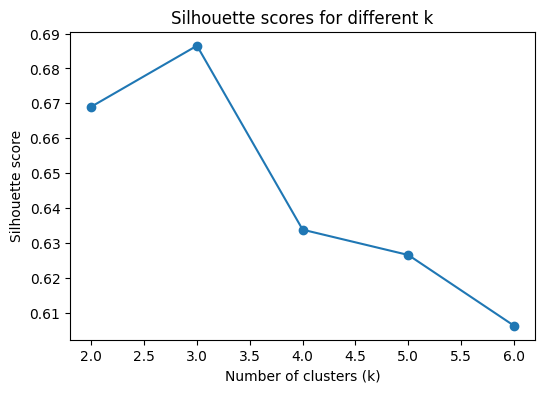

In [100]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Prepare data
belief_col = 'is_opened_rate_prev_smooth'
precision_col = 'open_rate_14d_prior_var'

clustering_df = model_df.sample(frac=0.05, random_state=42)[[belief_col, precision_col]]
print(f"Clustering on {len(clustering_df):,} samples")

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(clustering_df)

# Try k from 2 to 6
sil_scores = {}
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores[k] = score
    print(f"k={k}, silhouette score={score:.4f}")

# Find best k
best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k based on silhouette score: {best_k}")

# Optional: plot silhouette scores
plt.figure(figsize=(6,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores for different k")
plt.show()

Clustering on 473,552 samples


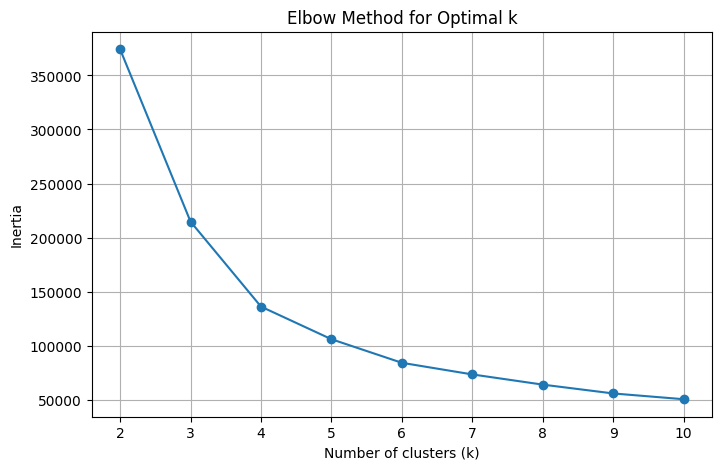

In [208]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Prepare data
belief_col = 'is_opened_rate_prev_smooth'
precision_col = 'open_rate_14d_prior_var'

clustering_df = model_df.sample(frac=0.4, random_state=42)[[belief_col, precision_col]]
print(f"Clustering on {len(clustering_df):,} samples")

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(clustering_df)

# Run KMeans for k = 2 to 10 and collect inertia
inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [45]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Prepare data
belief_col = 'is_opened_rate_prev_smooth'
precision_col = 'open_rate_14d_prior_var'

clustering_df = model_df.sample(frac=0.4, random_state=42)\
                            [[belief_col, precision_col]]

print(f"Clustering on {len(clustering_df):,} samples")

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(clustering_df)

# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# Get cluster centers (in standardized space)
centers = kmeans.cluster_centers_

# Example: decide mapping based on belief_col mean (first dimension)
# Suppose: lowest belief = Dormant, highest belief = Loyal, middle = Occasional
order = np.argsort(centers[:, 0])   # sort by belief_col centroid

# Create mapping dictionary
cluster_mapping = {order[0]: 0,   # Dormant
                   order[1]: 2,   # Occasional
                   order[2]: 1}   # Loyal

# Apply mapping
labels_mapped = np.array([cluster_mapping[l] for l in labels])

# Add mapped labels back
clustering_df['cluster'] = labels_mapped

# Show cluster statistics
print("\nCluster Summary:")
print(clustering_df.groupby('cluster').agg({
    belief_col: ['mean', 'count'],
    precision_col: 'mean'
}).round(4))

Clustering on 473,552 samples

Cluster Summary:
        is_opened_rate_prev_smooth         open_rate_14d_prior_var
                              mean   count                    mean
cluster                                                           
0                           0.0546  341219                  0.0190
1                           0.8045   39792                  0.0514
2                           0.3686   92541                  0.1583


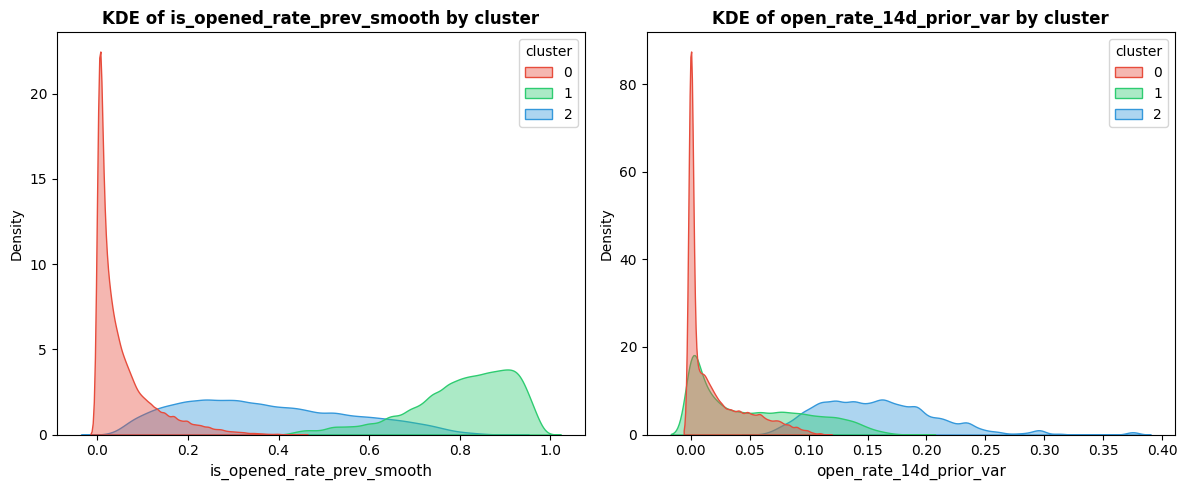

/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn/T/ipykernel_77440/1769802685.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Cluster", fontsize=10)


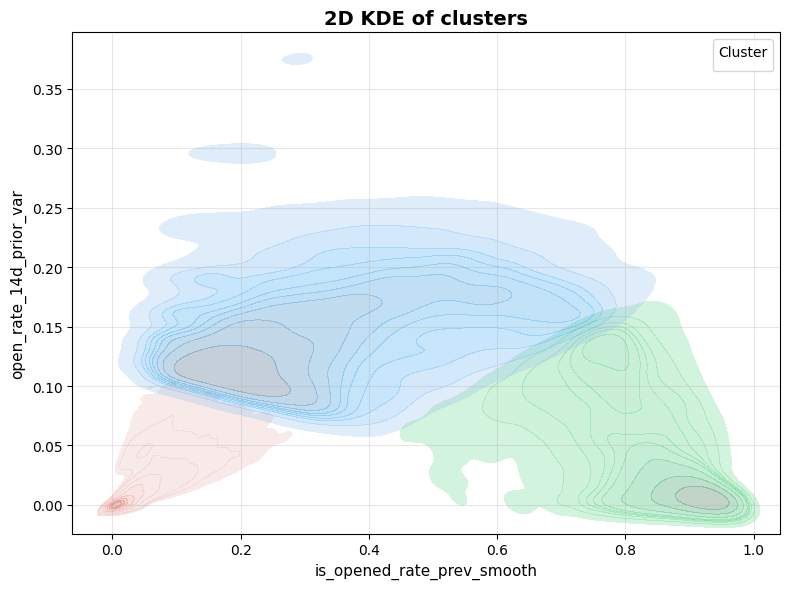

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define a consistent color palette for clusters with SPECIFIC colors
clusters = sorted(clustering_df['cluster'].unique())

# Option 1: Define specific hex colors for each cluster
cluster_colors = {
    0: '#e74c3c',  # Red for Dormant
    1: '#2ecc71',  # Green for Loyal
    2: '#3498db'   # Blue for Occasional
    
}

# Option 2: Or use named colors
# cluster_colors = {
#     0: 'green',
#     1: 'red', 
#     2: 'blue'
# }

# Option 3: Or use RGB tuples
# cluster_colors = {
#     0: (0.18, 0.8, 0.44),   # Green
#     1: (0.91, 0.3, 0.24),   # Red
#     2: (0.20, 0.63, 0.86)   # Blue
# }

# --- 1D KDE plots for each feature ---
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.kdeplot(
    data=clustering_df, x=belief_col, hue="cluster",
    fill=True, common_norm=False, alpha=0.4,
    palette=cluster_colors, ax=axes[0]
)
axes[0].set_title(f"KDE of {belief_col} by cluster", fontsize=12, fontweight='bold')
axes[0].set_xlabel(belief_col, fontsize=11)

sns.kdeplot(
    data=clustering_df, x=precision_col, hue="cluster",
    fill=True, common_norm=False, alpha=0.4,
    palette=cluster_colors, ax=axes[1]
)
axes[1].set_title(f"KDE of {precision_col} by cluster", fontsize=12, fontweight='bold')
axes[1].set_xlabel(precision_col, fontsize=11)

plt.tight_layout()
plt.show()

# --- 2D KDE plot ---
plt.figure(figsize=(8,6))
for c in clusters:
    subset = clustering_df[clustering_df['cluster'] == c]
    sns.kdeplot(
        x=subset[belief_col], 
        y=subset[precision_col], 
        fill=True, alpha=0.3,
        color=cluster_colors[c], 
        label=f"Cluster {c}"
    )
plt.title("2D KDE of clusters", fontsize=14, fontweight='bold')
plt.xlabel(belief_col, fontsize=11)
plt.ylabel(precision_col, fontsize=11)
plt.legend(title="Cluster", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# First, add cluster labels back to main dataframe
# We need to merge based on the indices that weren't dropped
df['cluster'] = None
df.loc[clustering_df.index, 'cluster'] = clustering_df['cluster']

# Convert sent_at to datetime and extract month
df['sent_month'] = pd.to_datetime(df['sent_at']).dt.to_period('M')

# Check cluster distribution by month
monthly_clusters = df[df['cluster'].notna()].groupby(['sent_month', 'cluster']).size().unstack(fill_value=0)

# Show as percentages
monthly_clusters_pct = monthly_clusters.div(monthly_clusters.sum(axis=1), axis=0) * 100

print("Cluster Distribution by Month (%):")
print(monthly_clusters_pct.round(2))

# Also show absolute counts
print("\n\nCluster Distribution by Month (counts):")
print(monthly_clusters)

# Summary statistics to check stability
print("\n\nCluster Stability Check:")
print("Standard deviation of % across months:")
print(monthly_clusters_pct.std().round(2))
print("\nLow std dev (<2-3%) = stable clusters across time")

Cluster Distribution by Month (%):
cluster         0      1      2
sent_month                     
2021-04     83.59   0.95  15.46
2021-05     70.15   9.25  20.60
2021-06     83.96   4.75  11.29
2021-07     73.55   5.51  20.94
2021-08     79.86   2.10  18.04
2021-09     86.42   4.04   9.54
2021-10     85.55   3.69  10.76
2021-11     85.09   4.34  10.56
2021-12     85.46   3.08  11.46
2022-01     83.24   4.02  12.74
2022-02     81.95   4.44  13.61
2022-03     81.92   3.22  14.86
2022-04     81.72   3.77  14.51
2022-05     84.02   2.51  13.47
2022-06     80.52   4.12  15.36
2022-07     77.92   4.10  17.98
2022-08     78.36   3.68  17.96
2022-09     76.51   6.74  16.75
2022-10     69.90   6.36  23.73
2022-11     70.96   5.36  23.68
2022-12     63.33   7.37  29.29
2023-01     60.40   7.81  31.79
2023-02     59.89  18.17  21.94
2023-03     59.06  26.13  14.81
2023-04     40.37  43.08  16.55


Cluster Distribution by Month (counts):
cluster         0     1      2
sent_month                  

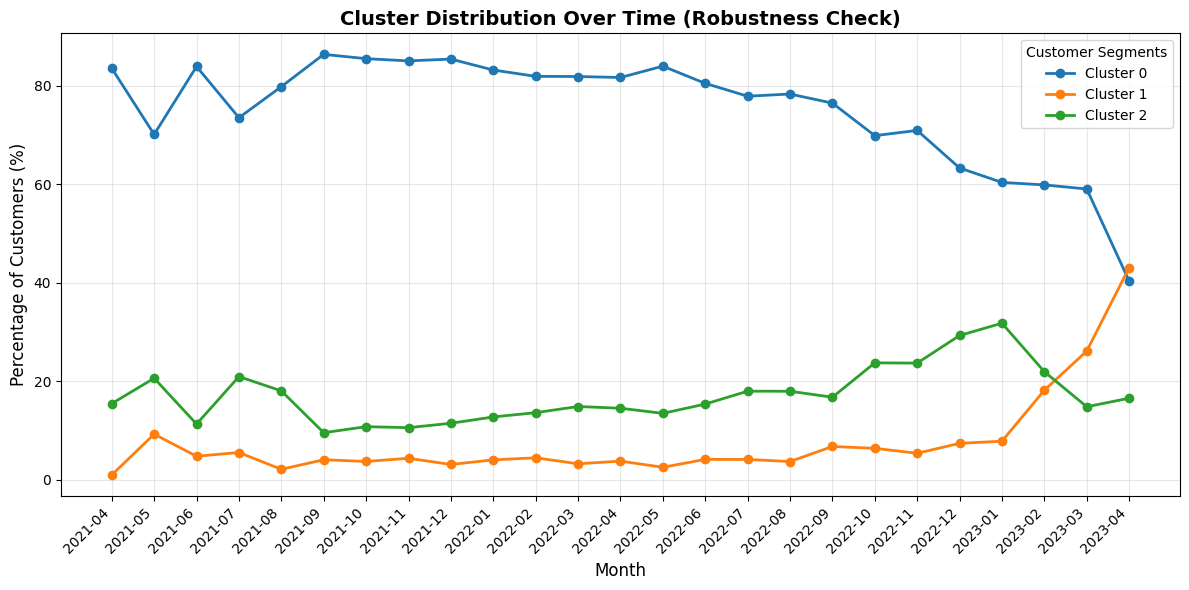


Interpretation:
- Flat lines = stable clusters (good robustness)
- Trending lines = changing customer behavior over time
- Volatile lines = seasonality or external factors affecting segments


In [48]:
import matplotlib.pyplot as plt

# Create the line plot
plt.figure(figsize=(12, 6))

# Plot each cluster
for cluster in monthly_clusters_pct.columns:
    plt.plot(monthly_clusters_pct.index.astype(str), 
             monthly_clusters_pct[cluster], 
             marker='o', 
             linewidth=2, 
             label=f'Cluster {cluster}')

plt.xlabel('Month', fontsize=12)
plt.ylabel('Percentage of Customers (%)', fontsize=12)
plt.title('Cluster Distribution Over Time (Robustness Check)', fontsize=14, fontweight='bold')
plt.legend(title='Customer Segments', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print interpretation helper
print("\nInterpretation:")
print("- Flat lines = stable clusters (good robustness)")
print("- Trending lines = changing customer behavior over time")
print("- Volatile lines = seasonality or external factors affecting segments")

/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn/T/ipykernel_77440/3560638687.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


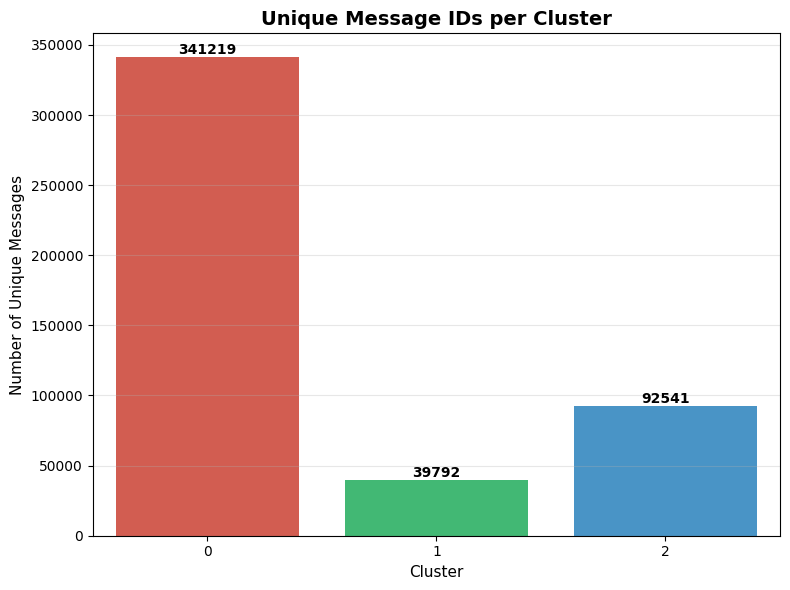

In [49]:
# --- Histogram of unique client IDs per cluster ---
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate unique client counts per cluster
unique_counts = df.groupby('cluster')['message_id'].nunique().reset_index()
unique_counts.rename(columns={'message_id': 'unique_message_count'}, inplace=True)

# Plot histogram (bar chart) of unique client IDs per cluster
plt.figure(figsize=(8,6))
sns.barplot(
    data=unique_counts,
    x='cluster',
    y='unique_message_count',
    palette=[cluster_colors[c] for c in unique_counts['cluster']]
)

# Add labels on top of bars
for idx, row in unique_counts.iterrows():
    plt.text(
        idx, row['unique_message_count'] + 0.5,   # position slightly above bar
        str(row['unique_message_count']),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title("Unique Message IDs per Cluster", fontsize=14, fontweight='bold')
plt.xlabel("Cluster", fontsize=11)
plt.ylabel("Number of Unique Messages", fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn/T/ipykernel_77440/3146813115.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


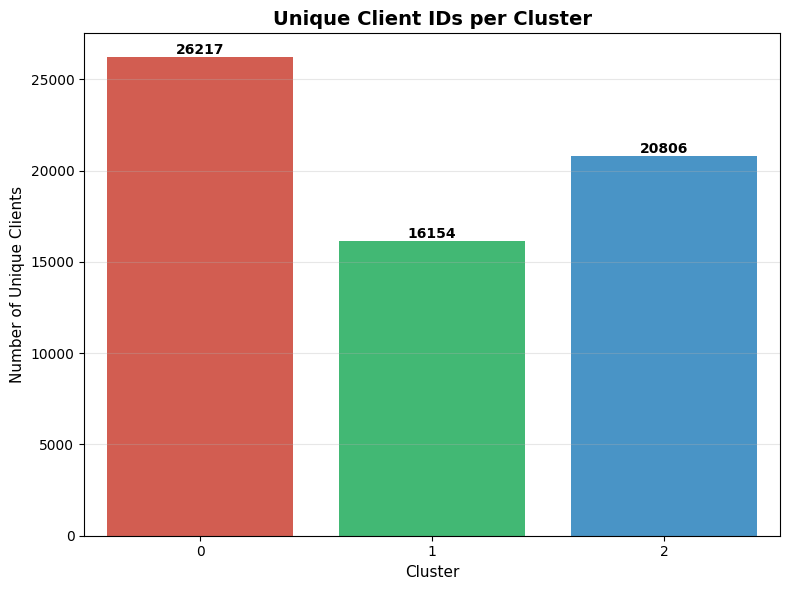

In [50]:
# --- Histogram of unique client IDs per cluster ---
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate unique client counts per cluster
unique_counts = df.groupby('cluster')['client_id'].nunique().reset_index()
unique_counts.rename(columns={'client_id': 'unique_client_count'}, inplace=True)

# Plot histogram (bar chart) of unique client IDs per cluster
plt.figure(figsize=(8,6))
sns.barplot(
    data=unique_counts,
    x='cluster',
    y='unique_client_count',
    palette=[cluster_colors[c] for c in unique_counts['cluster']]
)

# Add labels on top of bars
for idx, row in unique_counts.iterrows():
    plt.text(
        idx, row['unique_client_count'] + 0.5,   # position slightly above bar
        str(row['unique_client_count']),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title("Unique Client IDs per Cluster", fontsize=14, fontweight='bold')
plt.xlabel("Cluster", fontsize=11)
plt.ylabel("Number of Unique Clients", fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Train-Test Split

In [51]:
X = model_df[[col for col in model_df.columns if col != 'is_opened']]
y = model_df[['is_opened']]

In [52]:
from sklearn.model_selection import train_test_split

# Perform train-test split
train_ids, test_ids = train_test_split(
    model_df['client_id'].unique(), 
    test_size=0.2,      # 30% goes to test set
    random_state=42     # reproducibility
)


In [53]:
len(train_ids), len(test_ids)

(18178, 4545)

In [114]:
X_train = X[X['client_id'].isin(train_ids)]
X_test = X[X['client_id'].isin(test_ids)]
y_train = y[X['client_id'].isin(train_ids)]
y_test  = y[X['client_id'].isin(test_ids)]

(X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]), X_test.shape[0] / (X_train.shape[0] + X_test.shape[0]))

(0.7986444583535001, 0.20135554164649994)

We are not interested in to analyze how strong the model is to predict future, we want to analyze how well the model can generalize the opening behavior based on given time frame.

In [115]:
X_train = X_train.drop(columns = ['message_id', 'client_id'])
X_test = X_test.drop(columns = ['message_id', 'client_id'])

In [116]:
X_train.shape, X_test.shape

((945500, 24), (238381, 24))

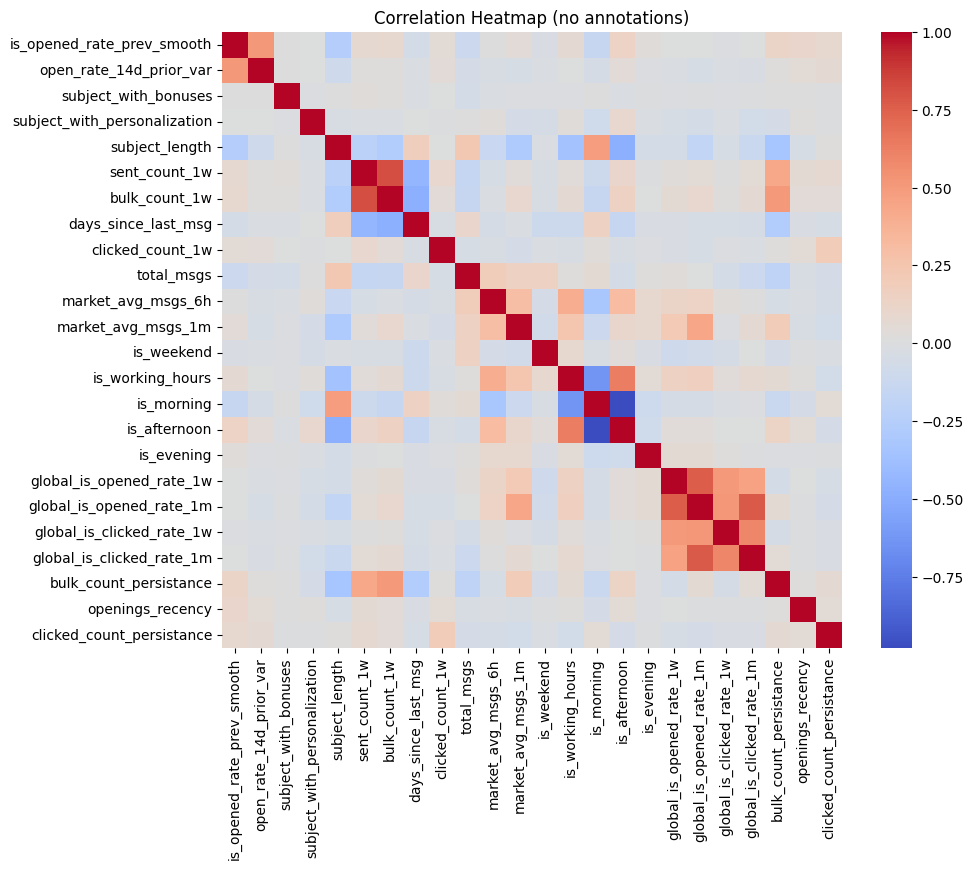

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = X_train.corr()

# Plot heatmap without numbers
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=False, cbar=True)

plt.title("Correlation Heatmap (no annotations)")
plt.show()

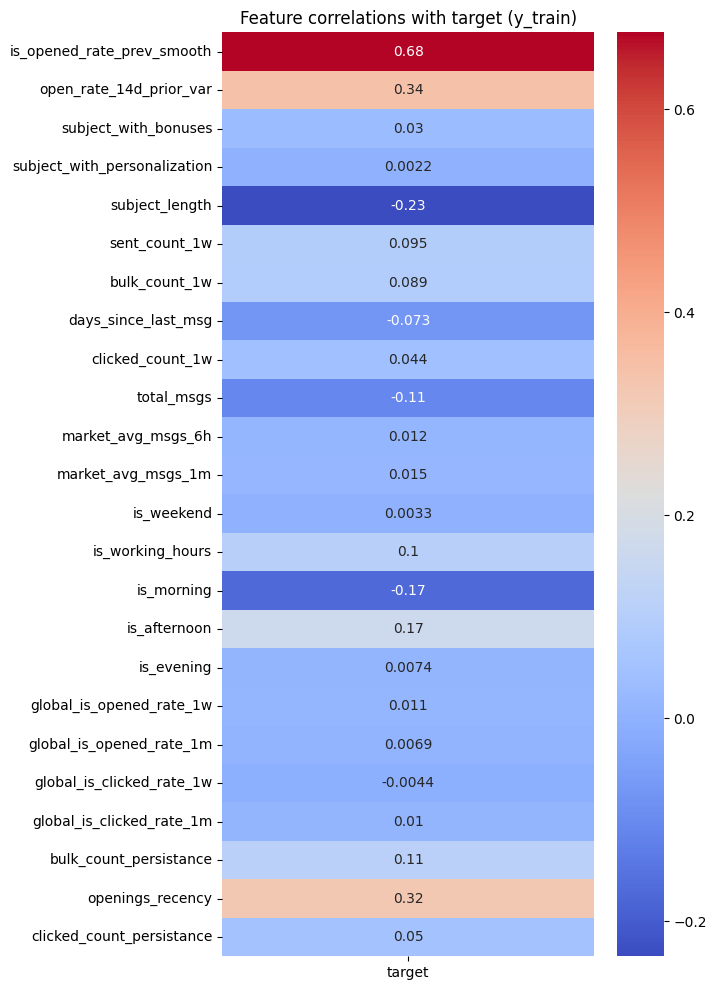

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine X_train and y_train into one DataFrame
corr_df = X_train.copy()
corr_df['target'] = y_train

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Extract only correlations with target
target_corr = corr_matrix[['target']].drop('target')

# Plot heatmap
plt.figure(figsize=(6, len(target_corr)/2))
sns.heatmap(target_corr, cmap="coolwarm", annot=True, cbar=True)

plt.title("Feature correlations with target (y_train)")
plt.show()

# XGBoost

In [119]:
import random
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score

# Global seed for reproducibility
random_seed = 42

random.seed(random_seed)
np.random.seed(random_seed)

# Split training into train/validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=random_seed,      # use shared seed
    stratify=y_train
)

# Define base model
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=random_seed,      # XGBoost seed
    n_jobs=1                       # optional: stricter determinism
)

# Smaller hyperparameter space for speed
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Randomized search with fewer iterations
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=5,                      # fewer random combinations
    scoring='roc_auc',
    cv=[(range(len(y_train_sub)), range(len(y_train_sub)))],  # dummy CV (fit on all)
    verbose=1,
    n_jobs=-1,
    random_state=random_seed       # RandomizedSearchCV seed
)

# Fit model on train subset, validate on val
random_search.fit(X_train_sub, y_train_sub)

print("Best parameters:", random_search.best_params_)

# Evaluate on validation set
best_model = random_search.best_estimator_
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

# Final evaluation on test set
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_proba))


Fitting 1 folds for each of 5 candidates, totalling 5 fits


/Users/macbookpro/Documents/DSDM/Econ_for_Data/Capstone/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [20:29:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/macbookpro/Documents/DSDM/Econ_for_Data/Capstone/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [20:29:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/macbookpro/Documents/DSDM/Econ_for_Data/Capstone/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [20:29:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/macbookpro/Documents/DSDM/Econ_for_Data/Capstone/.venv/lib/python3.13/site-packages/xgboost/t

Best parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Validation Accuracy: 0.9245637228979376
Validation ROC AUC: 0.9486994333024625
Test Accuracy: 0.9239452808738952
Test ROC AUC: 0.9494416460447574


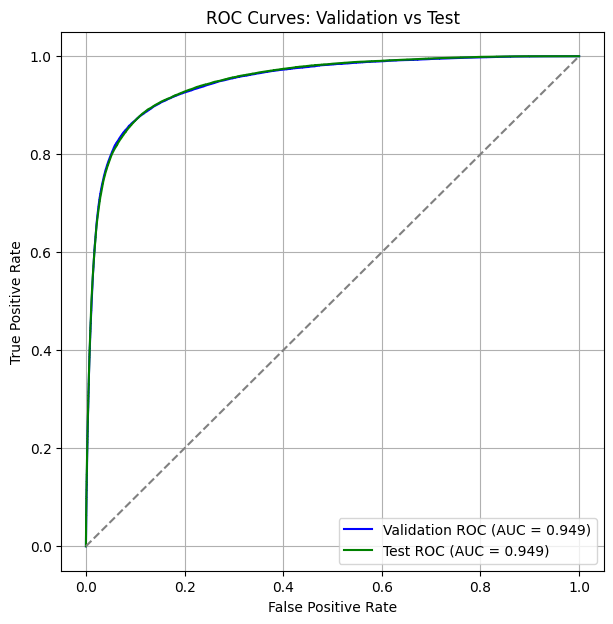

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

# --- Validation ROC ---
y_val_proba = best_model.predict_proba(X_val)[:, 1]
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
auc_val = roc_auc_score(y_val, y_val_proba)

# --- Test ROC ---
y_test_proba = best_model.predict_proba(X_test)[:, 1]
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# --- Plot both ---
plt.figure(figsize=(7,7))
plt.plot(fpr_val, tpr_val, label=f"Validation ROC (AUC = {auc_val:.3f})", color="blue")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})", color="green")

# Diagonal line for random classifier
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Validation vs Test")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

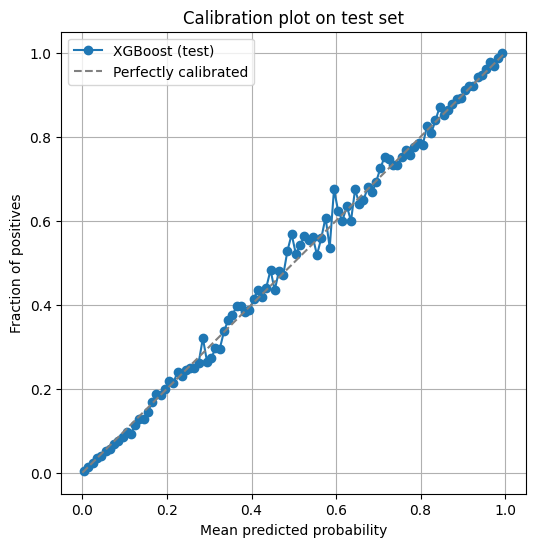

In [120]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Get predicted probabilities from your best model
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Compute calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=100)

# Plot calibration curve
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost (test)')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Perfectly calibrated')

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration plot on test set")
plt.legend()
plt.grid(True)
plt.show()

In [121]:
y_test.shape[0] / 100

2383.81

# Model Agnostic Analysis

## Shaps

/Users/macbookpro/Documents/DSDM/Econ_for_Data/Capstone/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn/T/ipykernel_77440/3057257057.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, X_test, show=False)


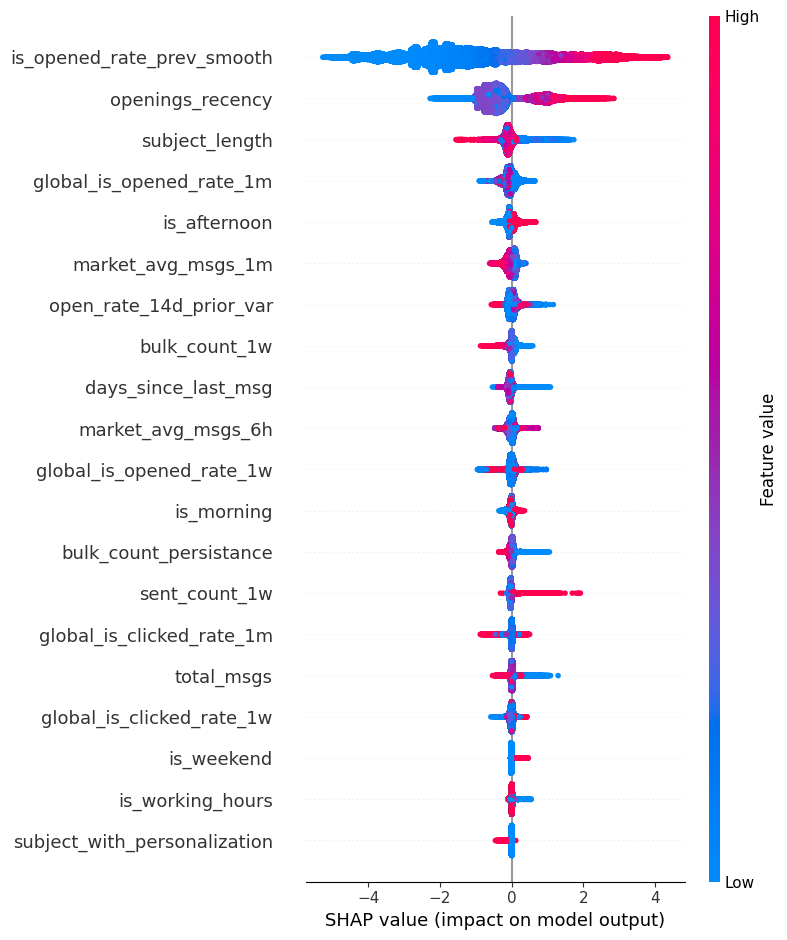

In [63]:
# ===============================
# Shap Beeswarm Plot
# ===============================
import shap
import matplotlib.pyplot as plt


explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for your test set
shap_values = explainer(X_test)

# 4. Visualize summary plot
shap.summary_plot(shap_values.values, X_test, show=False)
plt.show()

In [122]:
# Define the columns used for clustering
belief_col = 'is_opened_rate_prev_smooth'
precision_col = 'open_rate_14d_prior_var'

# 1) Standardize test data with the TRAINED scaler
model_df_cluster = scaler.transform(X_test[[belief_col, precision_col]])

# 2) Get raw KMeans labels on test
raw_labels = kmeans.predict(model_df_cluster)

# 3) Map raw labels to economic segments using cluster_mapping
X_test['cluster'] = np.array([cluster_mapping[l] for l in raw_labels])

# 4) (Optional) check that clusters look as expected
print(X_test.groupby('cluster')[belief_col].mean())


cluster
0    0.054655
1    0.803833
2    0.365426
Name: is_opened_rate_prev_smooth, dtype: float64


In [123]:
X_test['cluster'].value_counts(dropna=False)

cluster
0    171120
2     46221
1     21040
Name: count, dtype: int64

In [124]:
import numpy as np

# Wrapper class to add a predict method
class ModelWrapper:
    def __init__(self, model):
        self.model = model
    
    def predict(self, X):
        # Return probability of the positive class
        return self.model.predict_proba(X)[:, 1]

# Wrap your best_model
wrapped_model = ModelWrapper(best_model)

In [125]:
X_test[X_test.select_dtypes(bool).columns] = X_test.select_dtypes(bool).astype(int)

## ALE Plots

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected

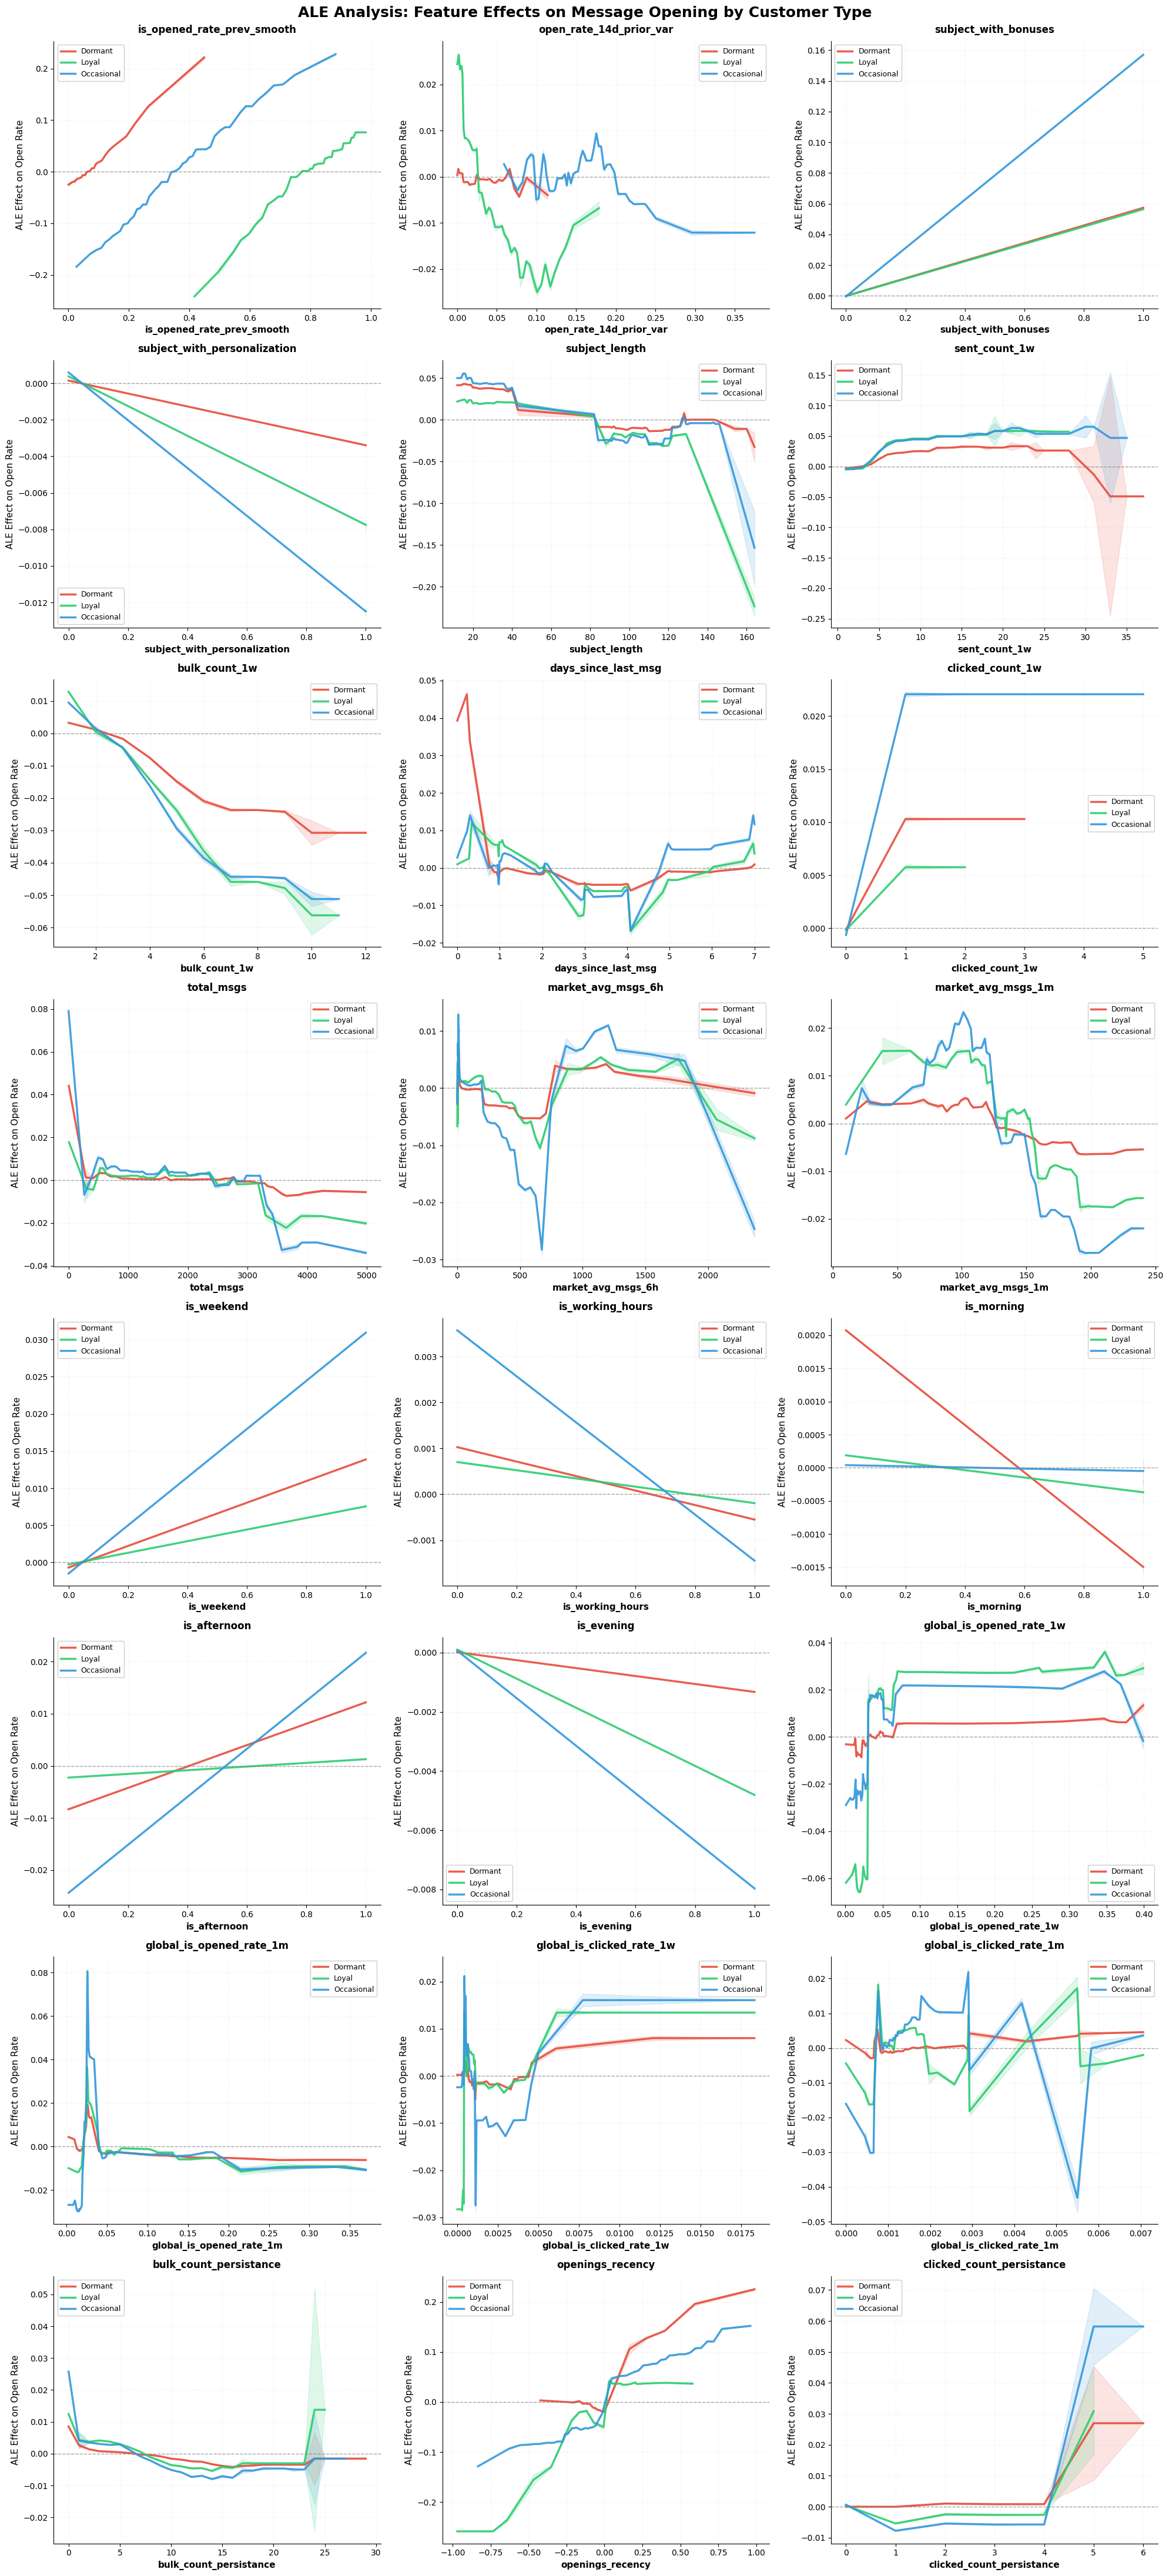


Plotted ALE for 24 features across 3 clusters

SUMMARY STATISTICS - Feature Effects by Cluster

IS_OPENED_RATE_PREV_SMOOTH:
  Dormant     : Range=0.2465, Mean=0.0020, Min=-0.0252, Max=0.2213 (n=50,000)
  Loyal       : Range=0.3180, Mean=-0.0014, Min=-0.2417, Max=0.0763 (n=21,040)
  Occasional  : Range=0.4119, Mean=0.0005, Min=-0.1842, Max=0.2277 (n=46,221)
  → Most sensitive: Occasional (range: 0.4119)
  → Least sensitive: Dormant (range: 0.2465)

OPEN_RATE_14D_PRIOR_VAR:
  Dormant     : Range=0.0060, Mean=-0.0007, Min=-0.0043, Max=0.0017 (n=50,000)
  Loyal       : Range=0.0514, Mean=-0.0045, Min=-0.0250, Max=0.0265 (n=21,040)
  Occasional  : Range=0.0215, Mean=-0.0001, Min=-0.0121, Max=0.0094 (n=46,221)
  → Most sensitive: Loyal (range: 0.0514)
  → Least sensitive: Dormant (range: 0.0060)

SUBJECT_WITH_BONUSES:
  Dormant     : Range=0.0574, Mean=0.0286, Min=-0.0001, Max=0.0573 (n=50,000)
  Loyal       : Range=0.0565, Mean=0.0281, Min=-0.0001, Max=0.0564 (n=21,040)
  Occasional  : Ran

In [126]:
import matplotlib.pyplot as plt
from PyALE import ale
import numpy as np
import pandas as pd

# Get all features except 'cluster'
features = [col for col in X_test.columns if col != 'cluster']

# Sample size per cluster
sample_size_per_cluster = 50_000
bins_size = 50
np.random.seed(42)

# Define colors and labels for each cluster
cluster_names = {0: 'Dormant', 1: 'Loyal', 2: 'Occasional'}  # Adjust based on your clusters
colors = [ '#e74c3c',   '#2ecc71', '#3498db',]  # Green (Loyal), Red (Dormant), Blue (Occasional)
cluster_ids = sorted(X_test['cluster'].unique())

# Calculate grid dimensions
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

# Create subplots with better spacing
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5.5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Store summary statistics for interpretation
summary_stats = []

# Plot ALE for each feature
for feature_idx, feat in enumerate(features):
    ax = axes[feature_idx]
    
    feature_stats = {'feature': feat, 'clusters': {}}
    
    # Plot ALE for each cluster
    for idx, cluster_id in enumerate(cluster_ids):
        # Filter data for this cluster
        X_cluster = X_test[X_test['cluster'] == cluster_id]
        
        # Sample if needed
        if len(X_cluster) > sample_size_per_cluster:
            sample_indices = np.random.choice(len(X_cluster), size=sample_size_per_cluster, replace=False)
            X_cluster_sample = X_cluster.iloc[sample_indices]
        else:
            X_cluster_sample = X_cluster
        
        # Remove 'cluster' column for model prediction (important!)
        X_cluster_features = X_cluster_sample.drop(columns=['cluster'])
        
        try:
            # Calculate ALE without plotting
            ale_results = ale(
                X=X_cluster_features,
                model=wrapped_model,
                feature=[feat],
                grid_size=bins_size,
                include_CI=True,
                C=0.95,
                plot=False
            )
            
            # Handle different PyALE return formats
            if isinstance(ale_results, tuple):
                ale_data = ale_results[0]
            else:
                ale_data = ale_results
            
            # Extract x and y values properly
            if isinstance(ale_data, pd.DataFrame):
                x_vals = ale_data.index.values
                y_vals = ale_data['eff'].values
                lower_ci = ale_data['lowerCI_95%'].values if 'lowerCI_95%' in ale_data.columns else None
                upper_ci = ale_data['upperCI_95%'].values if 'upperCI_95%' in ale_data.columns else None
            else:
                # Dictionary format
                x_vals = ale_data.get('bin_centers', np.arange(len(ale_data['eff'])))
                y_vals = ale_data['eff']
                lower_ci = ale_data.get('lowerCI_95%', None)
                upper_ci = ale_data.get('upperCI_95%', None)
            
            # Store statistics for interpretation
            cluster_label = cluster_names.get(cluster_id, f'Cluster {cluster_id}')
            feature_stats['clusters'][cluster_label] = {
                'mean_effect': np.mean(y_vals),
                'max_effect': np.max(y_vals),
                'min_effect': np.min(y_vals),
                'range': np.max(y_vals) - np.min(y_vals),
                'n_samples': len(X_cluster_sample)
            }
            
            # Plot the ALE effect
            ax.plot(x_vals, y_vals, 
                    color=colors[idx], 
                    linewidth=2.5, 
                    label=cluster_label,
                    alpha=0.9)
            
            # Add confidence intervals if available
            if lower_ci is not None and upper_ci is not None:
                ax.fill_between(
                    x_vals,
                    lower_ci,
                    upper_ci,
                    alpha=0.15,
                    color=colors[idx]
                )
        
        except Exception as e:
            print(f"Error processing {feat} for cluster {cluster_id}: {str(e)}")
            continue
    
    summary_stats.append(feature_stats)
    
    # Formatting
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel(feat, fontsize=11, fontweight='semibold')
    ax.set_ylabel('ALE Effect on Open Rate', fontsize=11)
    ax.set_title(f'{feat}', fontsize=12, fontweight='bold', pad=10)
    ax.legend(loc='best', fontsize=9, framealpha=0.95)
    ax.grid(True, alpha=0.25, linestyle=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('ALE Analysis: Feature Effects on Message Opening by Customer Type', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\nPlotted ALE for {n_features} features across {len(cluster_ids)} clusters")

# Print summary interpretation
print("\n" + "="*80)
print("SUMMARY STATISTICS - Feature Effects by Cluster")
print("="*80)

for stat in summary_stats:
    print(f"\n{stat['feature'].upper()}:")
    for cluster, metrics in stat['clusters'].items():
        print(f"  {cluster:12s}: Range={metrics['range']:.4f}, "
              f"Mean={metrics['mean_effect']:.4f}, "
              f"Min={metrics['min_effect']:.4f}, "
              f"Max={metrics['max_effect']:.4f} "
              f"(n={metrics['n_samples']:,})")
    
    # Identify which cluster is most/least affected
    ranges = {c: m['range'] for c, m in stat['clusters'].items()}
    most_sensitive = max(ranges, key=ranges.get)
    least_sensitive = min(ranges, key=ranges.get)
    print(f"  → Most sensitive: {most_sensitive} (range: {ranges[most_sensitive]:.4f})")
    print(f"  → Least sensitive: {least_sensitive} (range: {ranges[least_sensitive]:.4f})")

print("\n" + "="*80)

## Partial Dependence Plots

Calculating PDP plots...


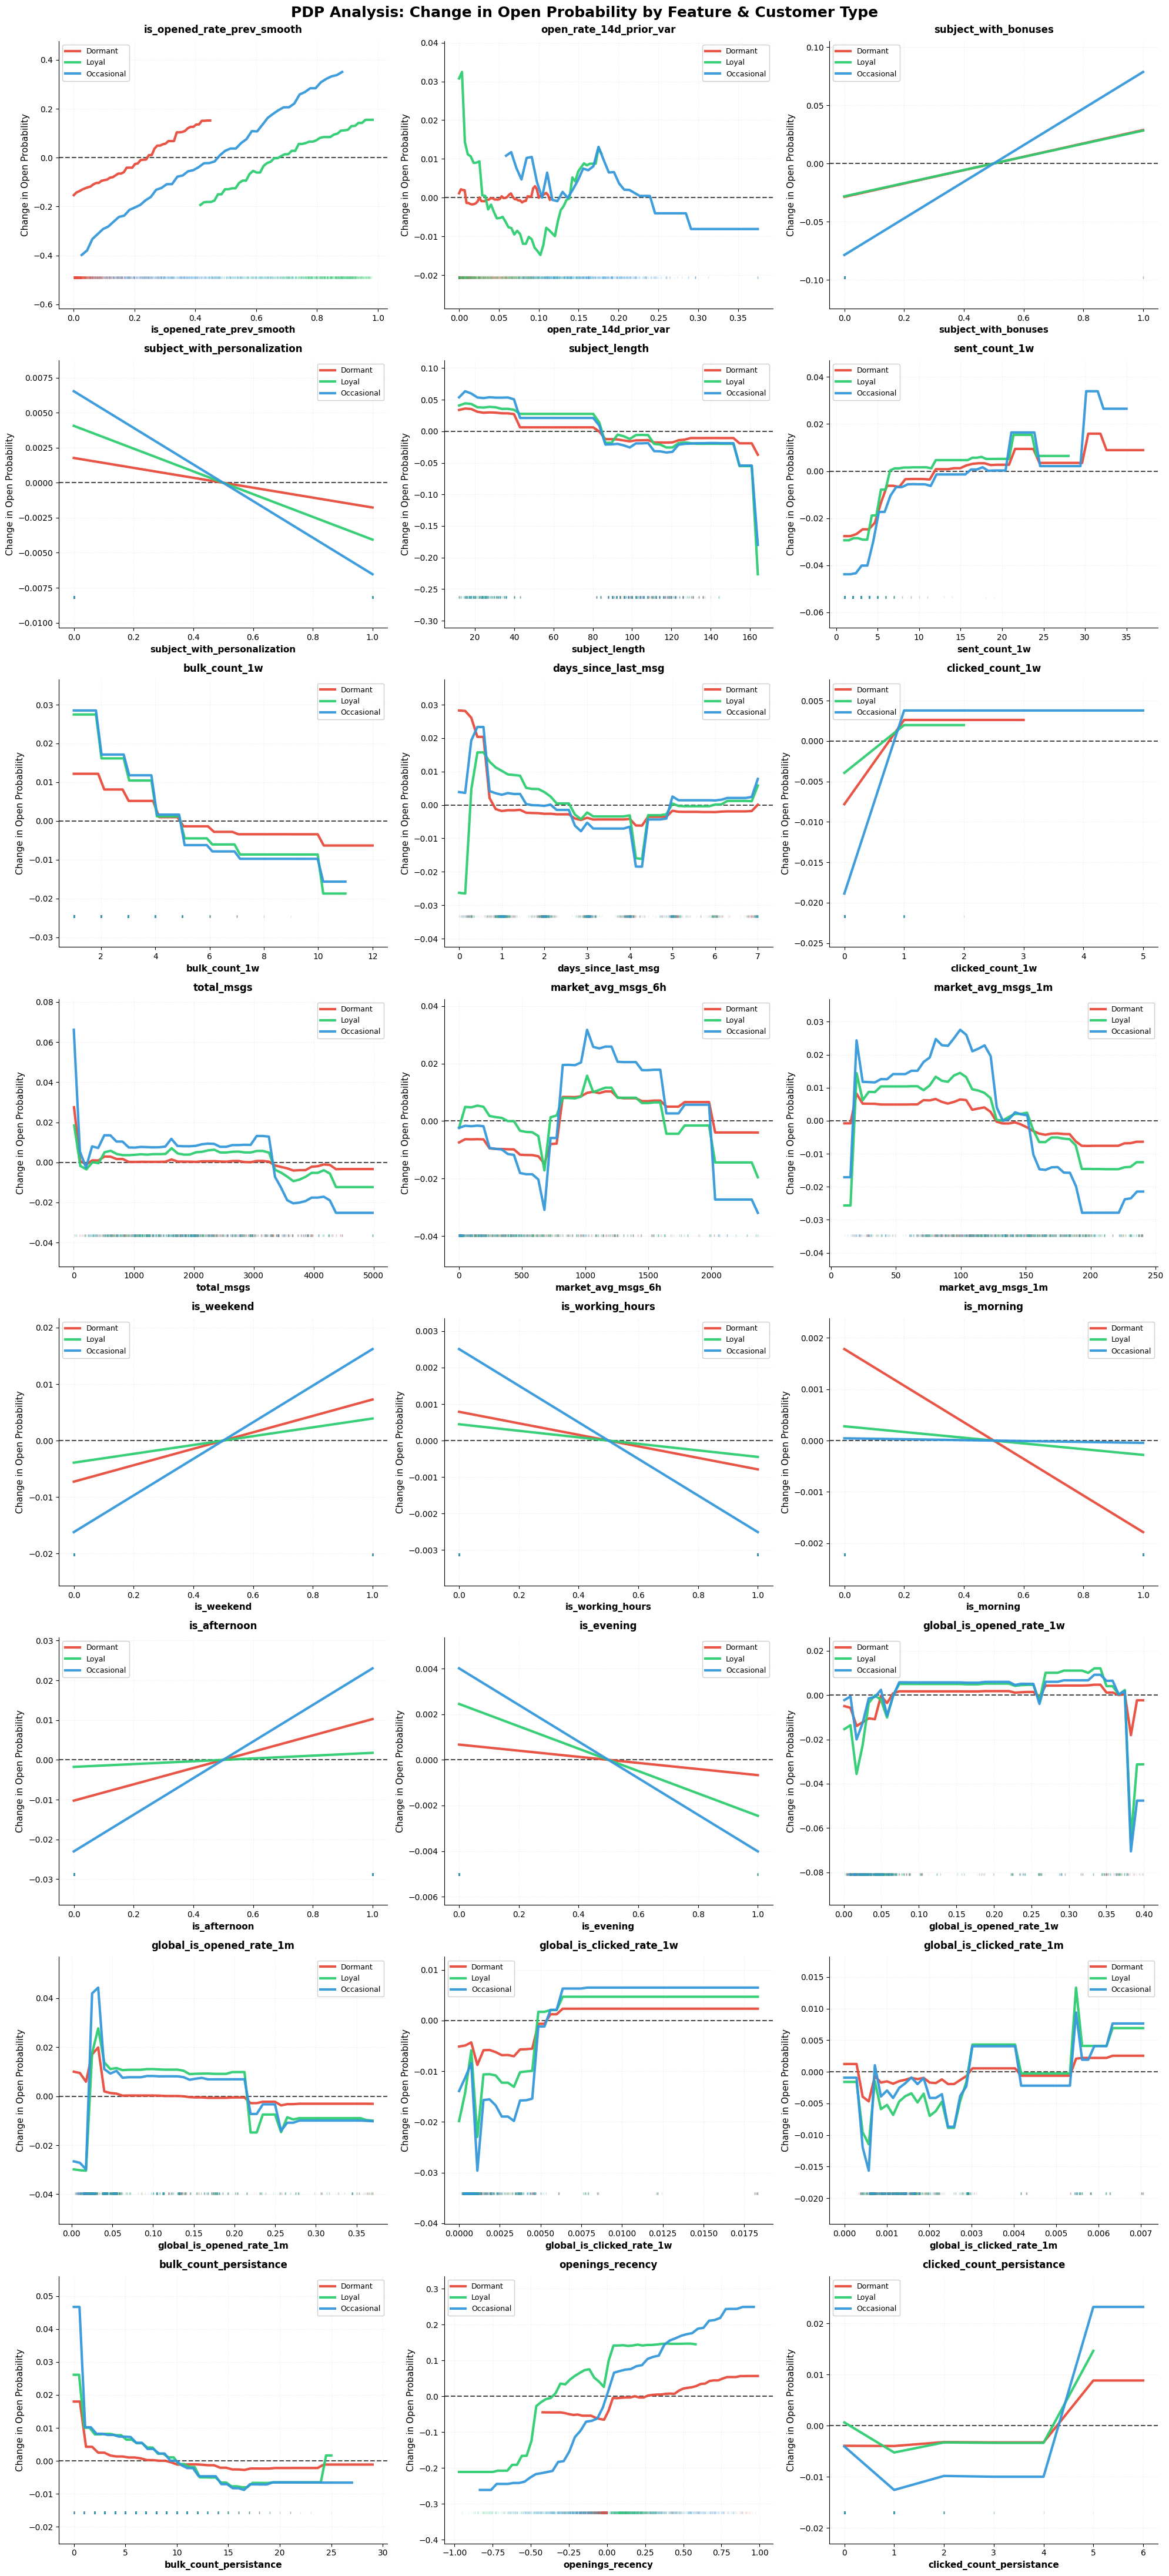


Plotted PDP for 24 features across 3 clusters

SUMMARY STATISTICS - Feature Effects by Cluster (PDP)

IS_OPENED_RATE_PREV_SMOOTH:
  Dormant     : Range=0.3051, Mean=0.0000, Min=-0.1533, Max=0.1518, Baseline=0.1589 (n=50,000)
  Loyal       : Range=0.3485, Mean=-0.0000, Min=-0.1936, Max=0.1548, Baseline=0.7573 (n=21,040)
  Occasional  : Range=0.7485, Mean=0.0000, Min=-0.3980, Max=0.3505, Baseline=0.4774 (n=46,221)
  → Most sensitive: Occasional (range: 0.7485)
  → Least sensitive: Dormant (range: 0.3051)

OPEN_RATE_14D_PRIOR_VAR:
  Dormant     : Range=0.0047, Mean=0.0000, Min=-0.0017, Max=0.0030, Baseline=0.0570 (n=50,000)
  Loyal       : Range=0.0472, Mean=0.0000, Min=-0.0148, Max=0.0324, Baseline=0.8219 (n=21,040)
  Occasional  : Range=0.0212, Mean=-0.0000, Min=-0.0081, Max=0.0131, Baseline=0.3809 (n=46,221)
  → Most sensitive: Loyal (range: 0.0472)
  → Least sensitive: Dormant (range: 0.0047)

SUBJECT_WITH_BONUSES:
  Dormant     : Range=0.0574, Mean=-0.0000, Min=-0.0287, Max=0.0287, 

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin

# Create a sklearn-compatible wrapper
class SklearnModelWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make your model sklearn-compatible for PDP"""
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])  # Binary classification
    
    def fit(self, X, y=None):
        # Already fitted, just return self
        return self
    
    def predict(self, X):
        """Predict class labels"""
        proba = self.predict_proba(X)
        return (proba[:, 1] > 0.5).astype(int)
    
    def predict_proba(self, X):
        """Predict class probabilities"""
        if hasattr(self.model, 'predict_proba'):
            return self.model.predict_proba(X)
        else:
            # For wrapped models, call directly
            proba_pos = self.model.predict(X)
            return np.column_stack([1 - proba_pos, proba_pos])

# Wrap your model
sklearn_model = SklearnModelWrapper(wrapped_model)

# Get all features except 'cluster'
features = [col for col in X_test.columns if col != 'cluster']

# Sample size per cluster
sample_size_per_cluster = 50_000
grid_resolution = 50
np.random.seed(42)

# Define colors and labels for each cluster
cluster_names = {0: 'Dormant', 1: 'Loyal', 2: 'Occasional'}
colors = ['#e74c3c', '#2ecc71', '#3498db']  # Red (Dormant), Green (Loyal), Blue (Occasional)
cluster_ids = sorted(X_test['cluster'].unique())

# Calculate grid dimensions
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

# Create subplots with better spacing
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5.5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Store summary statistics
summary_stats = []

# Calculate PDP for all features
print("Calculating PDP plots...")
pdp_cache = {}

for feature_idx, feat in enumerate(features):
    feature_data = {}
    
    for idx, cluster_id in enumerate(cluster_ids):
        # Filter data for this cluster
        X_cluster = X_test[X_test['cluster'] == cluster_id]
        
        # Sample if needed
        if len(X_cluster) > sample_size_per_cluster:
            sample_indices = np.random.choice(len(X_cluster), size=sample_size_per_cluster, replace=False)
            X_cluster_sample = X_cluster.iloc[sample_indices]
        else:
            X_cluster_sample = X_cluster
        
        # Remove 'cluster' column for model prediction
        X_cluster_features = X_cluster_sample.drop(columns=['cluster'])
        
        try:
            # Manual PDP calculation
            feature_values = X_cluster_features[feat].values
            
            # Create grid of values for this feature
            if X_cluster_features[feat].nunique() <= 10:
                # Discrete feature - use actual values
                grid_values = np.sort(X_cluster_features[feat].unique())
            else:
                # Continuous feature - create grid
                grid_values = np.linspace(
                    X_cluster_features[feat].min(),
                    X_cluster_features[feat].max(),
                    grid_resolution
                )
            
            pdp_values = []
            
            # Calculate PDP for each grid point
            for grid_val in grid_values:
                # Create counterfactual dataset
                X_counterfactual = X_cluster_features.copy()
                X_counterfactual[feat] = grid_val
                
                # Predict and average
                predictions = sklearn_model.predict_proba(X_counterfactual)[:, 1]
                avg_prediction = np.mean(predictions)
                pdp_values.append(avg_prediction)
            
            pdp_values = np.array(pdp_values)
            
            # CENTER THE VALUES: subtract the mean to show change from baseline
            baseline = np.mean(pdp_values)
            pdp_centered = pdp_values - baseline
            
            # Store for plotting
            feature_data[cluster_id] = {
                'grid_values': grid_values,
                'pdp_values': pdp_centered,  # Centered values
                'pdp_absolute': pdp_values,   # Keep absolute for reference
                'baseline': baseline,
                'n_samples': len(X_cluster_sample)
            }
        
        except Exception as e:
            print(f"Error processing {feat} for cluster {cluster_id}: {str(e)}")
            continue
    
    pdp_cache[feat] = feature_data

# Plot everything with INDIVIDUAL y-axis scales
for feature_idx, feat in enumerate(features):
    ax = axes[feature_idx]
    
    if feat not in pdp_cache or not pdp_cache[feat]:
        print(f"Skipping {feat} - no data")
        continue
    
    feature_stats = {'feature': feat, 'clusters': {}}
    
    # Plot PDP for each cluster
    for idx, cluster_id in enumerate(cluster_ids):
        if cluster_id not in pdp_cache[feat]:
            continue
        
        data = pdp_cache[feat][cluster_id]
        grid_values = data['grid_values']
        pdp_values = data['pdp_values']  # Centered values
        baseline = data['baseline']
        
        # Store statistics (using finite values only)
        cluster_label = cluster_names.get(cluster_id, f'Cluster {cluster_id}')
        valid_y = pdp_values[np.isfinite(pdp_values)]
        if len(valid_y) > 0:
            feature_stats['clusters'][cluster_label] = {
                'mean_effect': np.mean(valid_y),
                'max_effect': np.max(valid_y),
                'min_effect': np.min(valid_y),
                'range': np.max(valid_y) - np.min(valid_y),
                'baseline_prob': baseline,
                'n_samples': data['n_samples']
            }
        else:
            print(f"Warning: No valid values for {feat}, cluster {cluster_label}")
            continue
        
        # Plot the PDP effect with thicker lines for visibility
        ax.plot(grid_values, pdp_values, 
                color=colors[idx], 
                linewidth=3,
                label=cluster_label,
                alpha=0.95,
                zorder=3)
        
        # Add rug plot to show data distribution
        X_cluster = X_test[X_test['cluster'] == cluster_id]
        if len(X_cluster) > 1000:
            rug_sample = X_cluster[feat].sample(1000, random_state=42)
        else:
            rug_sample = X_cluster[feat]
        
        # Get current y-limits for rug placement (will be set after all lines plotted)
        rug_y_pos_temp = np.min(pdp_values) if len(pdp_values) > 0 else 0
    
    summary_stats.append(feature_stats)
    
    # Auto-scale y-axis with padding for each subplot individually
    ax.margins(y=0.15)  # Add 15% padding on y-axis
    
    # After auto-scaling, add rug plots at the bottom
    y_min, y_max = ax.get_ylim()
    for idx, cluster_id in enumerate(cluster_ids):
        if cluster_id not in pdp_cache[feat]:
            continue
        X_cluster = X_test[X_test['cluster'] == cluster_id]
        if len(X_cluster) > 1000:
            rug_sample = X_cluster[feat].sample(1000, random_state=42)
        else:
            rug_sample = X_cluster[feat]
        
        ax.scatter(rug_sample, 
                  np.ones(len(rug_sample)) * (y_min + 0.02 * (y_max - y_min)),
                  alpha=0.1, s=10, color=colors[idx], marker='|', linewidths=1, zorder=1)
    
    # Formatting with ZERO reference line (baseline)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
    
    ax.set_xlabel(feat, fontsize=11, fontweight='semibold')
    ax.set_ylabel('Change in Open Probability', fontsize=11)
    ax.set_title(f'{feat}', fontsize=12, fontweight='bold', pad=10)
    ax.legend(loc='best', fontsize=9, framealpha=0.95)
    ax.grid(True, alpha=0.25, linestyle=':', zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('PDP Analysis: Change in Open Probability by Feature & Customer Type', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\nPlotted PDP for {n_features} features across {len(cluster_ids)} clusters")

# Print summary interpretation
print("\n" + "="*80)
print("SUMMARY STATISTICS - Feature Effects by Cluster (PDP)")
print("="*80)

for stat in summary_stats:
    print(f"\n{stat['feature'].upper()}:")
    for cluster, metrics in stat['clusters'].items():
        print(f"  {cluster:12s}: Range={metrics['range']:.4f}, "
              f"Mean={metrics['mean_effect']:.4f}, "
              f"Min={metrics['min_effect']:.4f}, "
              f"Max={metrics['max_effect']:.4f}, "
              f"Baseline={metrics['baseline_prob']:.4f} "
              f"(n={metrics['n_samples']:,})")
    
    # Identify which cluster is most/least affected
    if stat['clusters']:
        ranges = {c: m['range'] for c, m in stat['clusters'].items()}
        most_sensitive = max(ranges, key=ranges.get)
        least_sensitive = min(ranges, key=ranges.get)
        print(f"  → Most sensitive: {most_sensitive} (range: {ranges[most_sensitive]:.4f})")
        print(f"  → Least sensitive: {least_sensitive} (range: {ranges[least_sensitive]:.4f})")

print("\n" + "="*80)

# Print interpretation guide
print("\nINTERPRETATION GUIDE:")
print("-" * 80)
print("PDP (Partial Dependence Plot) - CENTERED VERSION")
print()
print("Y-axis shows: CHANGE in predicted open probability from the baseline")
print("  • 0 = baseline (average prediction for this cluster)")
print("  • Positive values = feature increases open probability")
print("  • Negative values = feature decreases open probability")
print()
print("Benefits of centering:")
print("  • Easier to see effect direction and magnitude")
print("  • Each subplot uses its own scale for better visibility of slopes")
print("  • Direct comparison: which features have the strongest effects?")
print()
print("Key differences from ALE:")
print("  • PDP shows average effects, centering shows change from baseline")
print("  • ALE shows local effects accounting for feature correlations")
print("  • Both are useful: PDP for overall trends, ALE for causal interpretation")
print("="*80)

# Bayesian Updating Visualization

BAYESIAN UPDATING & RATIONAL INATTENTION VISUALIZATIONS

6. Bayesian Updating: How clusters process signals


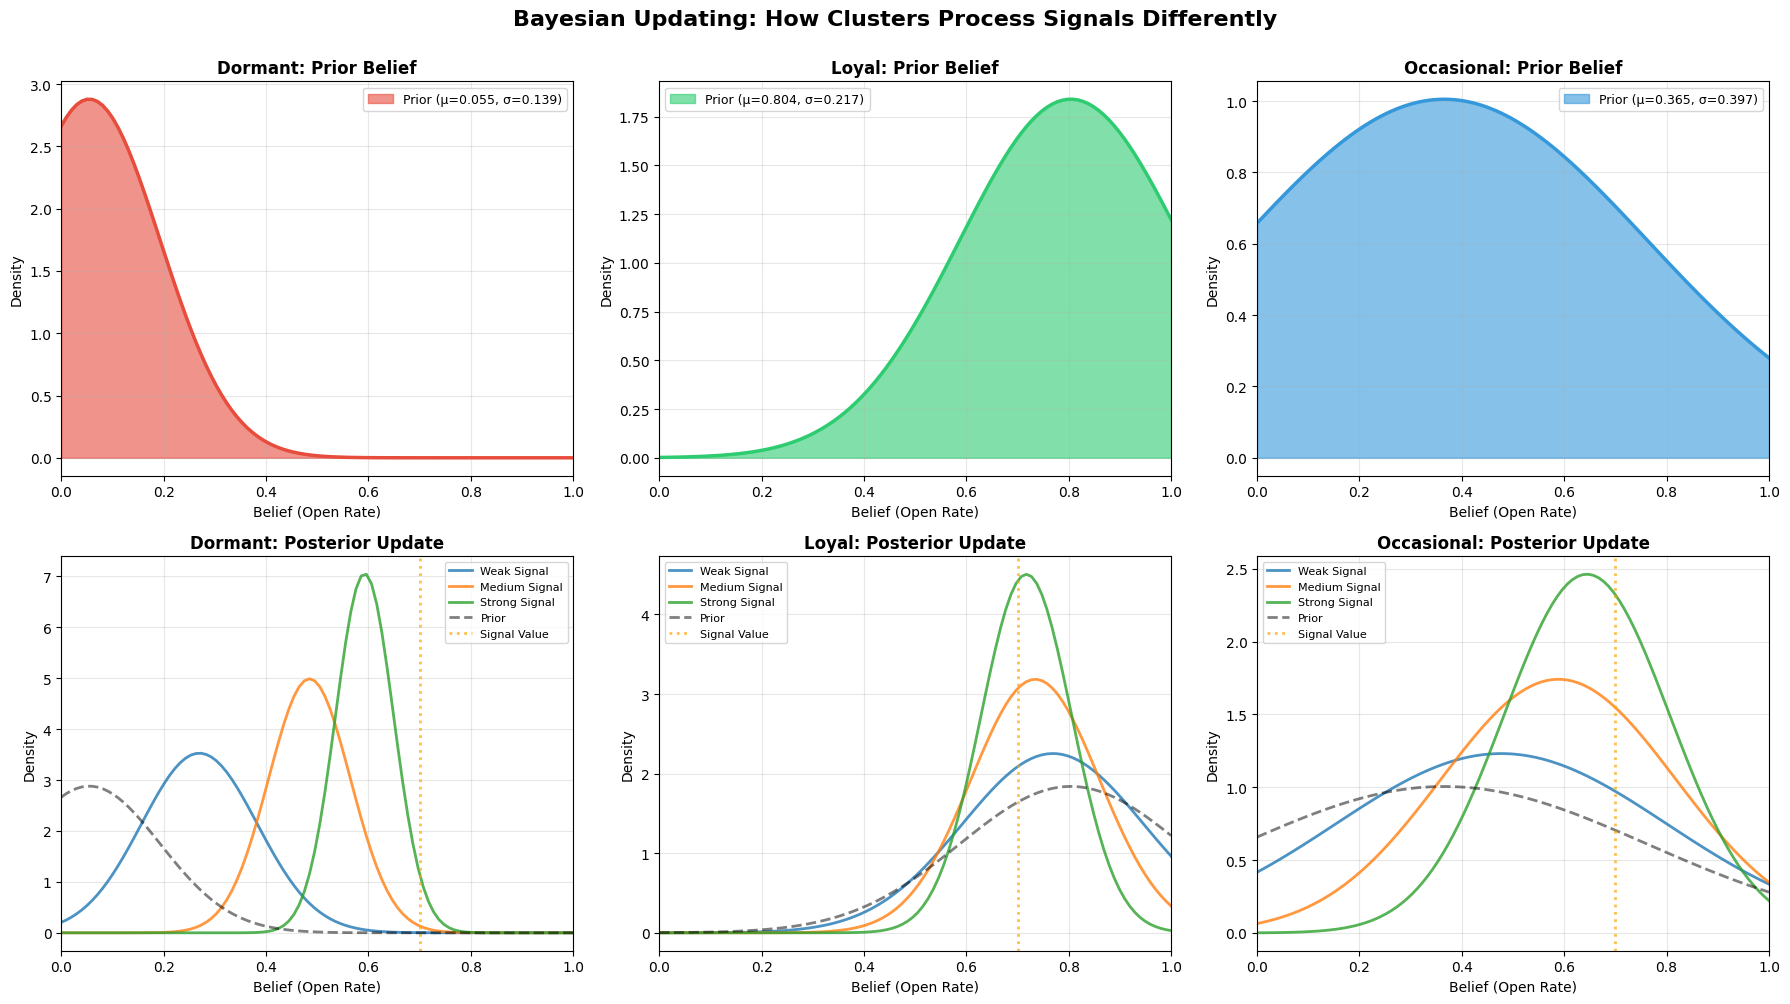

In [127]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# ============================================================================
# 6. BAYESIAN UPDATING VISUALIZATION
# Shows how signal strength changes posterior beliefs for each cluster
# ============================================================================

def plot_bayesian_updating(X_test, cluster_names, belief_col='is_opened_rate_prev_smooth',
                          precision_col='open_rate_14d_prior_var'):
    """
    Visualize Bayesian updating: Prior → Signal → Posterior
    Shows how different clusters update their beliefs differently
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    colors = ['#e74c3c', '#2ecc71', '#3498db']
    cluster_ids = sorted(cluster_names.keys())
    
    # Top row: Prior distributions
    for idx, cluster_id in enumerate(cluster_ids):
        ax = axes[0, idx]
        X_cluster = X_test[X_test['cluster'] == cluster_id]
        
        cluster_label = cluster_names[cluster_id]
        prior_mean = X_cluster[belief_col].mean()
        prior_std = np.sqrt(X_cluster[precision_col].mean())
        
        # Plot prior distribution
        x = np.linspace(0, 1, 100)
        prior_dist = stats.norm.pdf(x, prior_mean, prior_std)
        
        ax.fill_between(x, prior_dist, alpha=0.6, color=colors[idx], 
                       label=f'Prior (μ={prior_mean:.3f}, σ={prior_std:.3f})')
        ax.plot(x, prior_dist, color=colors[idx], linewidth=2.5)
        
        ax.set_title(f'{cluster_label}: Prior Belief', fontsize=12, fontweight='bold')
        ax.set_xlabel('Belief (Open Rate)', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
    
    # Bottom row: Signal precision effect
    for idx, cluster_id in enumerate(cluster_ids):
        ax = axes[1, idx]
        X_cluster = X_test[X_test['cluster'] == cluster_id]
        
        cluster_label = cluster_names[cluster_id]
        prior_mean = X_cluster[belief_col].mean()
        prior_precision = 1 / (X_cluster[precision_col].mean() + 1e-10)
        
        # Simulate different signal strengths
        signal_strengths = ['Weak', 'Medium', 'Strong']
        signal_precisions = [prior_precision * 0.5, prior_precision * 2, prior_precision * 5]
        signal_value = 0.7  # Positive signal
        
        x = np.linspace(0, 1, 100)
        
        for sig_label, sig_precision in zip(signal_strengths, signal_precisions):
            # Bayesian updating: combine prior and signal
            posterior_precision = prior_precision + sig_precision
            posterior_mean = (prior_precision * prior_mean + sig_precision * signal_value) / posterior_precision
            posterior_std = np.sqrt(1 / posterior_precision)
            
            posterior_dist = stats.norm.pdf(x, posterior_mean, posterior_std)
            ax.plot(x, posterior_dist, linewidth=2, label=f'{sig_label} Signal', alpha=0.8)
        
        # Plot prior for reference
        prior_std = np.sqrt(1 / prior_precision)
        prior_dist = stats.norm.pdf(x, prior_mean, prior_std)
        ax.plot(x, prior_dist, 'k--', linewidth=2, label='Prior', alpha=0.5)
        
        ax.axvline(x=signal_value, color='orange', linestyle=':', 
                  linewidth=2, label='Signal Value', alpha=0.7)
        
        ax.set_title(f'{cluster_label}: Posterior Update', fontsize=12, fontweight='bold')
        ax.set_xlabel('Belief (Open Rate)', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
    
    plt.suptitle('Bayesian Updating: How Clusters Process Signals Differently', 
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()





# ============================================================================
# EXAMPLE USAGE
# ============================================================================

wrapped_model = SklearnModelWrapper(wrapped_model)

if __name__ == "__main__":
    cluster_names = {0: 'Dormant', 1: 'Loyal', 2: 'Occasional'}
    
    print("="*80)
    print("BAYESIAN UPDATING & RATIONAL INATTENTION VISUALIZATIONS")
    print("="*80)
    
    # 6. Bayesian Updating
    print("\n6. Bayesian Updating: How clusters process signals")
    plot_bayesian_updating(X_test, cluster_names)
    


# Counterfactuals

THREE KEY COUNTERFACTUAL ANALYSES

COUNTERFACTUAL 1: OPTIMAL SIGNAL DESIGN UNDER FATIGUE

Economic Question: When attention is constrained by high message volume,
what signal structure (length + bonus) maximizes response?

Expected Findings:
- Under low fatigue: Longer subjects with bonus work well
- Under high fatigue: Short subjects with bonus become optimal
- Occasional customers show strongest sensitivity to this tradeoff


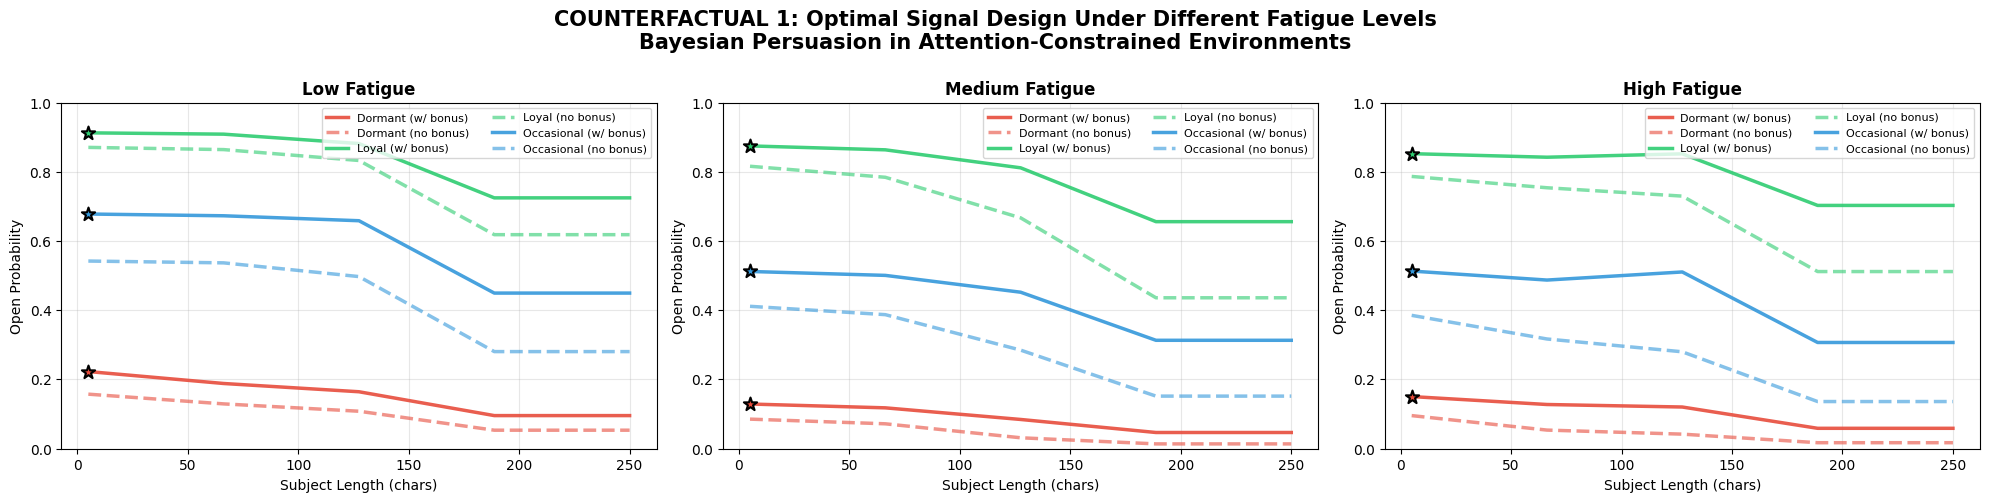

In [ ]:
# ============================================================================
# COUNTERFACTUAL 1: OPTIMAL SIGNAL DESIGN UNDER DIFFERENT FATIGUE LEVELS
# "Bayesian Persuasion in a Fatigued Environment"
# ============================================================================

import src.counterrfactuals_signal_design as counter_signal

cluster_names = {0: 'Dormant', 1: 'Loyal', 2: 'Occasional'}

print("="*80)
print("THREE KEY COUNTERFACTUAL ANALYSES")
print("="*80)

print("\n" + "="*80)
print("COUNTERFACTUAL 1: OPTIMAL SIGNAL DESIGN UNDER FATIGUE")
print("="*80)
print("\nEconomic Question: When attention is constrained by high message volume,")
print("what signal structure (length + bonus) maximizes response?")
print("\nExpected Findings:")
print("- Under low fatigue: Longer subjects with bonus work well")
print("- Under high fatigue: Short subjects with bonus become optimal")
print("- Occasional customers show strongest sensitivity to this tradeoff")


recs = counter_signal.counterfactual_signal_design_under_fatigue(X_test, wrapped_model, cluster_names)



COUNTERFACTUAL 2: MARKET COORDINATION ANALYSIS

Economic Question: What happens if the industry coordinates to reduce
total message volume vs. individual firms optimizing independently?

Expected Findings:
- Individual optimization (Nash) leads to over-messaging
- Coordinated reduction improves outcomes for all
- Loyal customers benefit most from coordination


/var/folders/bg/38ht234d5p50ytp9mrxf80nc0000gn/T/ipykernel_77440/1245245182.py:417: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


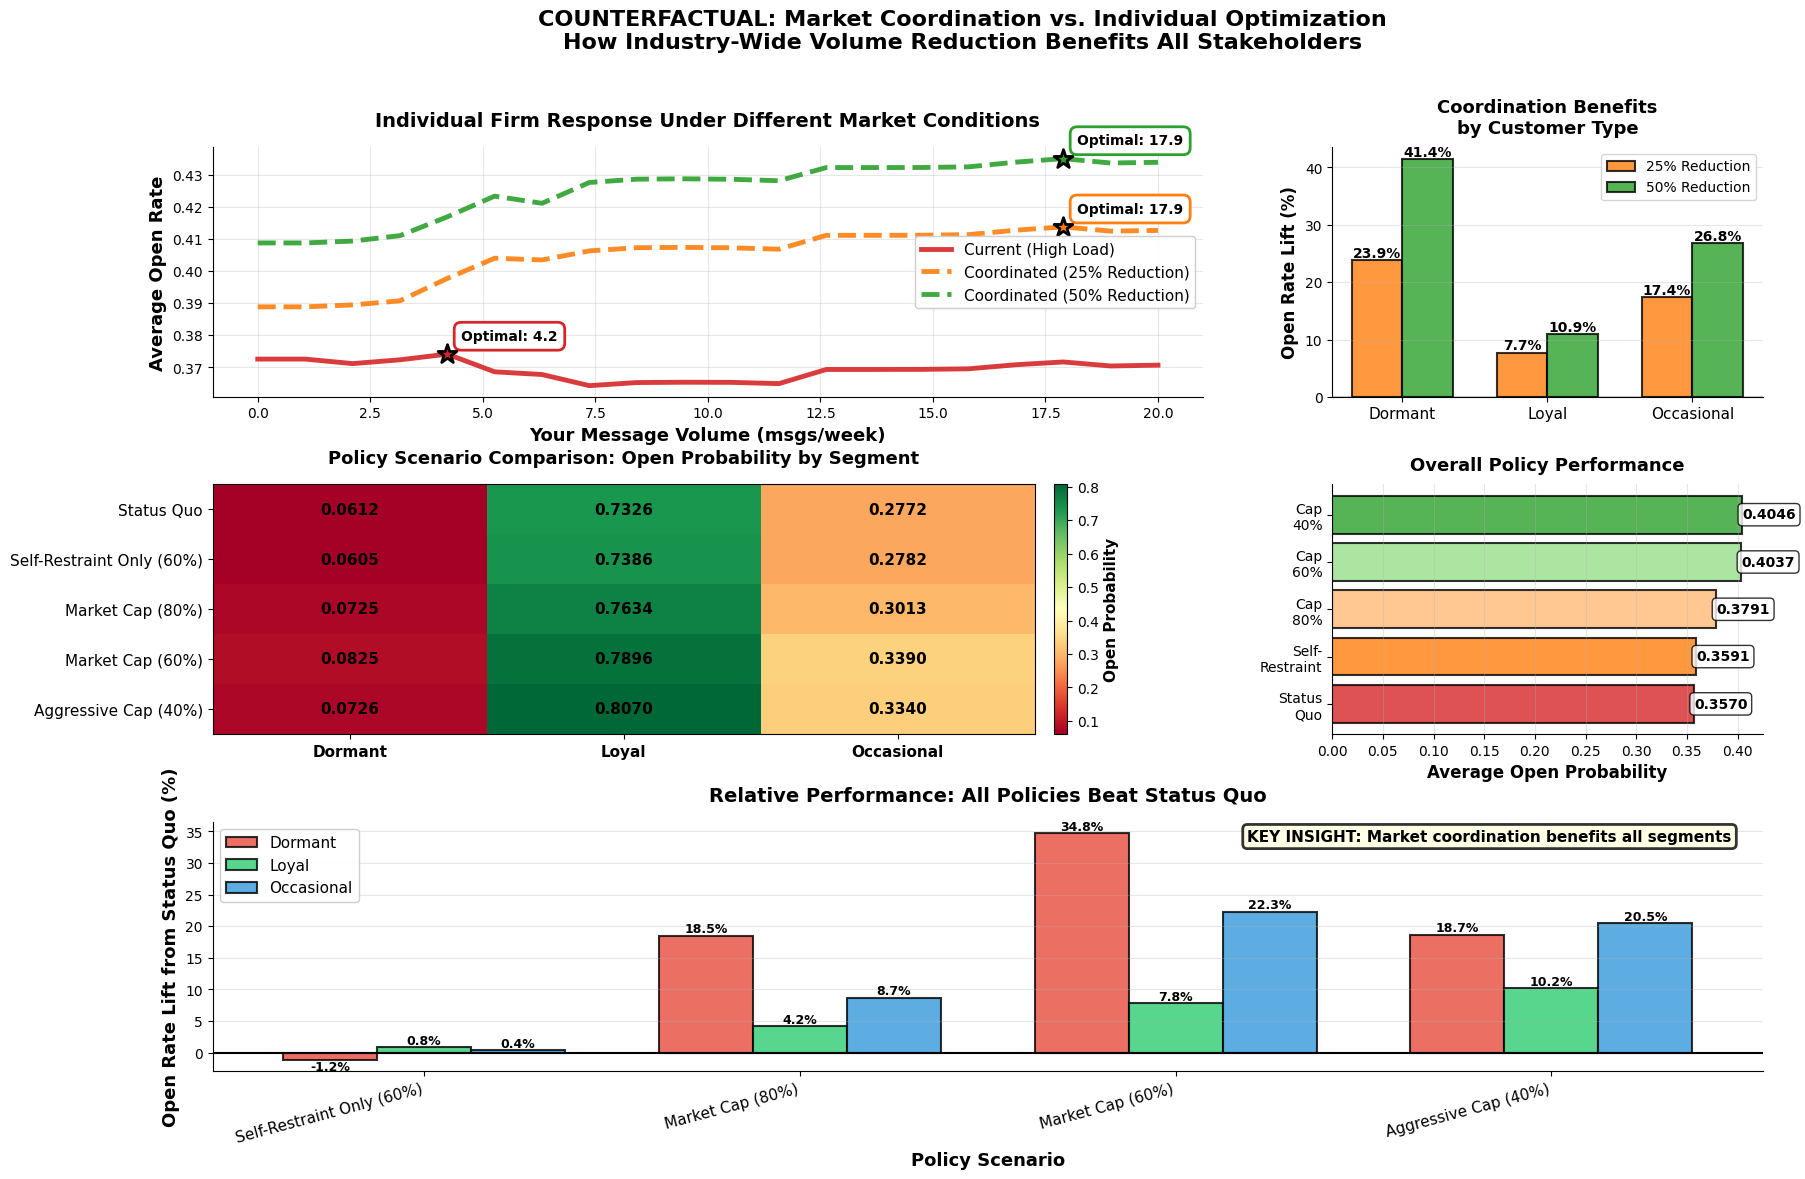


POLICY RECOMMENDATIONS TABLE:
                            Dormant     Loyal  Occasional   Average
policy                                                             
Status Quo                 0.061218  0.732561    0.277220  0.357000
Self-Restraint Only (60%)  0.060504  0.738579    0.278217  0.359100
Market Cap (80%)           0.072533  0.763414    0.301337  0.379095
Market Cap (60%)           0.082494  0.789569    0.339000  0.403688
Aggressive Cap (40%)       0.072642  0.807005    0.334020  0.404556



In [ ]:
# ================================================================================
# COUNTERFACTUAL 2: MARKET COORDINATION ANALYSIS
# ================================================================================

import src.counterfactuals_coordination as counter_coord


print("\n" + "="*80)
print("COUNTERFACTUAL 2: MARKET COORDINATION ANALYSIS")
print("="*80)
print("\nEconomic Question: What happens if the industry coordinates to reduce")
print("total message volume vs. individual firms optimizing independently?")
print("\nExpected Findings:")
print("- Individual optimization (Nash) leads to over-messaging")
print("- Coordinated reduction improves outcomes for all")
print("- Loyal customers benefit most from coordination")

cluster_names = {0: 'Dormant', 1: 'Loyal', 2: 'Occasional'}
policy_df = counter_coord.counterfactual_market_coordination(X_test, wrapped_model, cluster_names)

print("\n" + "="*80)
print("POLICY RECOMMENDATIONS TABLE:")
print("="*80)
print(policy_df.to_string())
print("\n" + "="*80)